<a href="https://colab.research.google.com/github/Isadora220825/MVP_CEP_Raisin-Quality-Control/blob/main/MVP_(Raisin_Quality_Control)_Isadora_Messenberg_231013387.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Explicação: Aqui chamamos todas as ferramentas que vamos usar
# ao longo do projeto. É boa prática importar tudo no início
# para saber de cara quais dependências o notebook tem.

import pandas as pd          # Explicação: manipulação de tabelas (DataFrames)
import numpy as np           # Explicação: operações matemáticas e arrays
import matplotlib.pyplot as plt  # Explicação: criação de gráficos
import seaborn as sns        # Explicação: gráficos estatísticos mais bonitos

# Explicação: configurações visuais globais para todos os gráficos
plt.rcParams['figure.figsize'] = (10, 5)  # tamanho padrão das figuras
plt.rcParams['axes.grid'] = True           # grade em todos os gráficos
sns.set_theme(style='whitegrid')           # estilo visual do seaborn

# Explicação: fixamos a seed global do numpy para garantir que
# resultados aleatórios sejam sempre os mesmos ao re-executar
np.random.seed(42)

print("Bibliotecas importadas com sucesso!")



Bibliotecas importadas com sucesso!


In [3]:
# Explicação: baixa o dataset direto do UCI Machine Learning Repository
# sem precisar fazer upload manual — qualquer pessoa pode rodar o notebook
!pip install ucimlrepo --quiet

from ucimlrepo import fetch_ucirepo

# Explicação: o ID 850 é o identificador do Raisin Dataset no UCI
raisin = fetch_ucirepo(id=850)

# Explicação: separa as features (X) e o target (y) em DataFrames
X_raw = raisin.data.features
y_raw = raisin.data.targets

# Explicação: junta tudo em um único DataFrame igual ao xlsx original
df = X_raw.copy()
df['Class'] = y_raw.iloc[:, 0].values

print("Dataset carregado direto do UCI!")

Dataset carregado direto do UCI!


In [4]:
# Explicação: .shape retorna (número de linhas, número de colunas)
# Esperamos (900, 8): 900 grãos e 8 colunas (7 features + 1 classe)
print("=== Dimensões do dataset ===")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

print("\n=== Primeiras 5 linhas ===")
# Explicação: .head() mostra as primeiras linhas para verificar
# se os dados foram carregados corretamente
display(df.head())

print("\n=== Últimas 5 linhas ===")
# Explicação: .tail() mostra as últimas linhas — útil para
# checar se o arquivo não foi truncado
display(df.tail())

=== Dimensões do dataset ===
Linhas: 900 | Colunas: 8

=== Primeiras 5 linhas ===


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen



=== Últimas 5 linhas ===


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni
899,85609,512.081774,215.271976,0.907345,89197,0.632020,1272.862,Besni


In [5]:
print("=== Tipos de dados por coluna ===")
# Explicação: .dtypes mostra o tipo de cada coluna
# Esperamos float64 para as features e object para a coluna Class
print(df.dtypes)

print("\n=== Valores faltantes por coluna ===")
# Explicação: .isnull().sum() conta quantos NaN (vazio) existe
# em cada coluna. Esperamos zeros em todas — o dataset é limpo.
print(df.isnull().sum())

# Explicação: exibe a mensagem de ausência total de faltantes
if df.isnull().sum().sum() == 0:
    print("\n Nenhum valor faltante encontrado. Dataset limpo!")
else:
    print("\n Atenção: há valores faltantes. Verificar antes de modelar.")


=== Tipos de dados por coluna ===
Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
Eccentricity       float64
ConvexArea           int64
Extent             float64
Perimeter          float64
Class               object
dtype: object

=== Valores faltantes por coluna ===
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

 Nenhum valor faltante encontrado. Dataset limpo!


=== Contagem por variedade ===
Class
Kecimen    450
Besni      450
Name: count, dtype: int64

=== Percentual por variedade ===
Class
Kecimen    50.0%
Besni      50.0%
Name: proportion, dtype: object


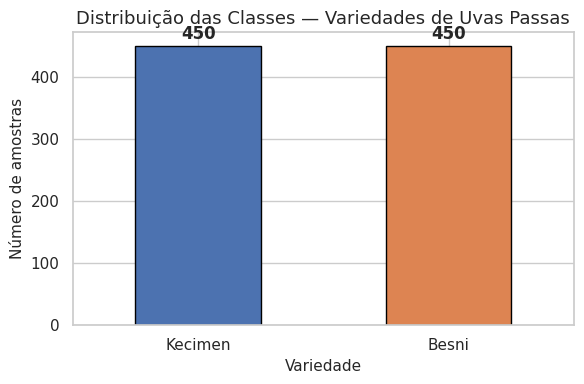


 Classes balanceadas: não será necessário SMOTE ou class_weight.


In [6]:
print("=== Contagem por variedade ===")
# Explicação: .value_counts() conta quantas amostras existem
# de cada classe. Esperamos 450 Kecimen e 450 Besni (balanceado)
contagem = df['Class'].value_counts()
print(contagem)

# Explicação: calculamos o percentual de cada classe para
# confirmar que o balanceamento é perfeito (50% / 50%)
print("\n=== Percentual por variedade ===")
print(df['Class'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Explicação: gráfico de barras para visualizar o balanceamento
fig, ax = plt.subplots(figsize=(6, 4))
contagem.plot(
    kind='bar',
    ax=ax,
    color=['#4C72B0', '#DD8452'],  # azul para Besni, laranja para Kecimen
    edgecolor='black',
    width=0.5
)

# Explicação: adicionamos rótulos com a contagem em cima de cada barra
for i, v in enumerate(contagem):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribuição das Classes — Variedades de Uvas Passas', fontsize=13)
ax.set_xlabel('Variedade', fontsize=11)
ax.set_ylabel('Número de amostras', fontsize=11)
ax.set_xticklabels(contagem.index, rotation=0)
plt.tight_layout()
plt.show()

print("\n Classes balanceadas: não será necessário SMOTE ou class_weight.")

In [7]:
print("=== Estatísticas descritivas ===")
# Explicação: .describe() calcula média, desvio padrão, mínimo,
# máximo e quartis de cada coluna numérica de uma vez.
# Isso nos dá uma visão rápida da escala de cada feature.
display(df.describe().round(2))

# Explicação: nota importante — as features têm escalas muito
# diferentes (Area vai até ~100.000, Eccentricity vai de 0 a 1).
# Por isso precisaremos de padronização (StandardScaler) antes
# de aplicar modelos sensíveis à escala, como SVM e Regressão Logística.
print("\n Atenção: features em escalas muito diferentes.")
print("   → Padronização (StandardScaler) será aplicada na Parte 3.")

=== Estatísticas descritivas ===


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.00,900.00,900.00,900.00,900.00,900.00,900.00
mean,87804.13,430.93,254.49,0.78,91186.09,0.70,1165.91
std,39002.11,116.04,49.99,0.09,40769.29,0.05,273.76
min,25387.00,225.63,143.71,0.35,26139.00,0.38,619.07
25%,59348.00,345.44,219.11,0.74,61513.25,0.67,966.41
50%,78902.00,407.80,247.85,0.80,81651.00,0.71,1119.51
75%,105028.25,494.19,279.89,0.84,108375.75,0.73,1308.39
max,235047.00,997.29,492.28,0.96,278217.00,0.84,2697.75



 Atenção: features em escalas muito diferentes.
   → Padronização (StandardScaler) será aplicada na Parte 3.


In [8]:
# Explicação: vamos comparar as médias de cada feature entre
# Kecimen e Besni para entender quais características mais
# diferenciam as duas variedades visualmente

print("=== Estatísticas por variedade ===\n")

# Explicação: .groupby() agrupa o DataFrame pela coluna Class
# e .describe() calcula as estatísticas para cada grupo
stats_por_classe = df.groupby('Class').describe().round(2)
display(stats_por_classe)

# Explicação: tabela mais simples — só a média de cada feature
# por variedade, para comparação direta
print("\n=== Média de cada feature por variedade ===")
medias = df.groupby('Class').mean().round(2)
display(medias)



=== Estatísticas por variedade ===



Area                                                               \
         count       mean       std      min       25%       50%        75%   
Class                                                                         
Besni    450.0  112194.79  39229.90  40702.0  83598.50  104426.5  135683.25   
Kecimen  450.0   63413.47  17727.77  25387.0  50466.25   61420.0   75153.00   

                  MajorAxisLength          ... Extent       Perimeter  \
              max           count    mean  ...    75%   max     count   
Class                                      ...                          
Besni    235047.0           450.0  509.00  ...   0.73  0.83     450.0   
Kecimen  180898.0           450.0  352.86  ...   0.74  0.84     450.0   

                                                                      
            mean     std     min      25%      50%      75%      max  
Class                                                                 
Besni    1348.13  246.80  771.80  1182.35  1305.80  1510.48  2697.75  
Kecimen   983.69  150.31  619.07   885.15   977.93  1073.22  2253.56  

[2 rows x 56 columns]


=== Média de cada feature por variedade ===


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
Class,,,,,,,
Besni,112194.79,509.00,279.62,0.82,116675.82,0.69,1348.13
Kecimen,63413.47,352.86,229.35,0.74,65696.36,0.71,983.69


=== Matriz de Correlação ===


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
Area,1.00,0.93,0.91,0.34,1.00,-0.01,0.96
MajorAxisLength,0.93,1.00,0.73,0.58,0.95,-0.20,0.98
MinorAxisLength,0.91,0.73,1.00,-0.03,0.90,0.15,0.83
Eccentricity,0.34,0.58,-0.03,1.00,0.35,-0.36,0.45
ConvexArea,1.00,0.95,0.90,0.35,1.00,-0.05,0.98
Extent,-0.01,-0.20,0.15,-0.36,-0.05,1.00,-0.17
Perimeter,0.96,0.98,0.83,0.45,0.98,-0.17,1.00


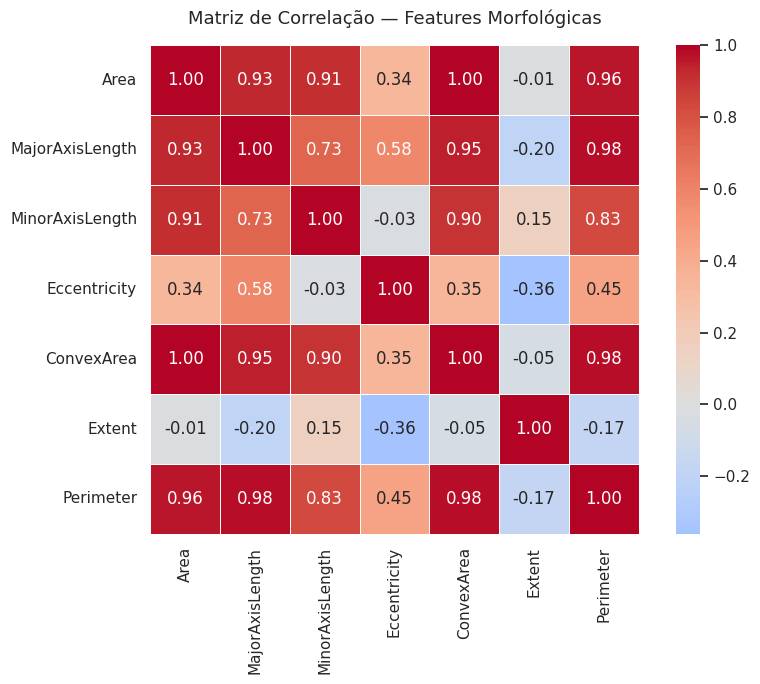


=== Pares com correlação > 0.95 ===
  Area ↔ ConvexArea: 1.0
  Area ↔ Perimeter: 0.96
  MajorAxisLength ↔ Perimeter: 0.98
  ConvexArea ↔ Perimeter: 0.98


In [9]:
# Explicação: a correlação mede o quanto duas variáveis
# "andam juntas". Valores próximos de 1 indicam correlação
# positiva forte (quando uma sobe, a outra também sobe).
# Isso é importante porque features muito correlacionadas
# carregam informação redundante.

# Explicação: selecionamos só as colunas numéricas (excluindo Class)
features = ['Area', 'MajorAxisLength', 'MinorAxisLength',
            'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']

# Explicação: .corr() calcula a matriz de correlação de Pearson
# entre todas as features numéricas
corr = df[features].corr().round(2)

print("=== Matriz de Correlação ===")
display(corr)

# Explicação: heatmap é a forma visual padrão de mostrar a
# matriz de correlação — cores quentes = correlação alta
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,          # Explicação: mostra o valor numérico em cada célula
    fmt='.2f',           # Explicação: formata com 2 casas decimais
    cmap='coolwarm',     # Explicação: azul = correlação negativa, vermelho = positiva
    center=0,            # Explicação: centraliza a escala de cores no zero
    square=True,         # Explicação: células quadradas, mais fácil de ler
    linewidths=0.5,      # Explicação: linhas separando as células
    ax=ax
)
ax.set_title('Matriz de Correlação — Features Morfológicas', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Explicação: identificamos pares com correlação muito alta (> 0.95)
# que podem ser candidatos à remoção por redundância
print("\n=== Pares com correlação > 0.95 ===")
pares_altos = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        val = abs(corr.iloc[i, j])
        if val > 0.95:
            pares_altos.append((features[i], features[j], round(val, 3)))

if pares_altos:
    for f1, f2, v in pares_altos:
        print(f"  {f1} ↔ {f2}: {v}")
else:
    print("  Nenhum par acima de 0.95")

/tmp/ipykernel_9706/1219679943.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9706/1219679943.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9706/1219679943.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9706/1219679943.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9706/1219679943.py:16: FutureWarning: 

P

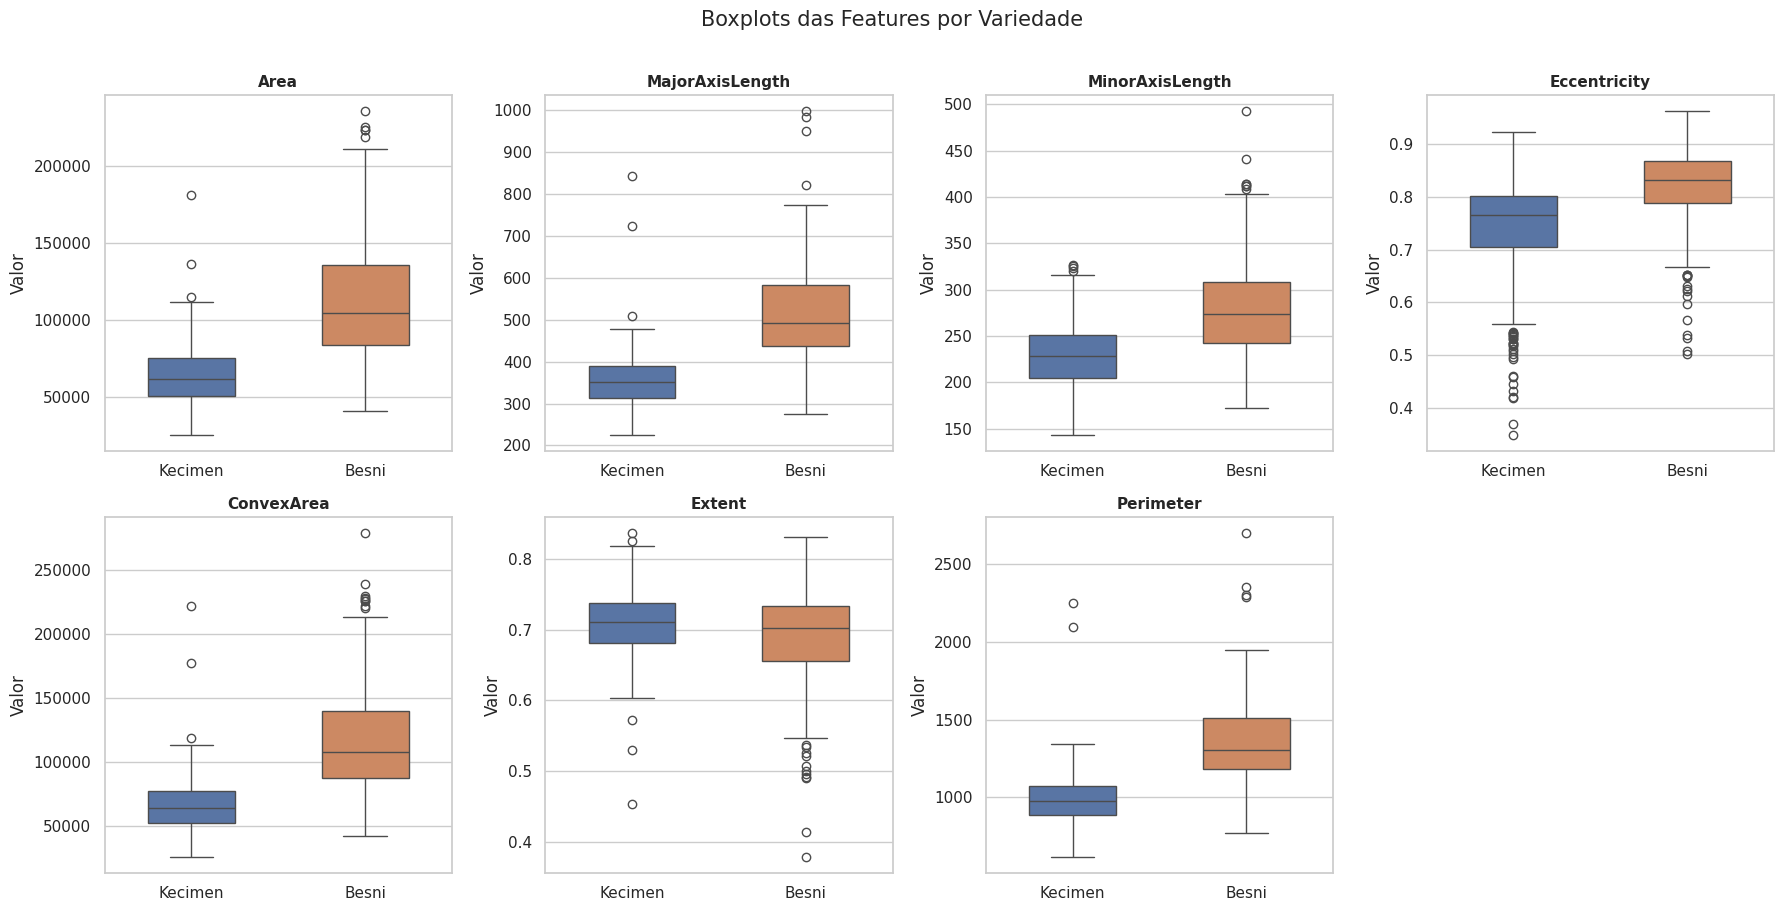

In [10]:
# Explicação: o boxplot mostra a distribuição de cada feature
# separada por variedade (Kecimen vs Besni).
# Caixas bem separadas = feature discriminativa (boa para o modelo).
# Caixas sobrepostas = feature pouco útil para classificar.

# Explicação: criamos uma figura com 7 subplots, um por feature
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Boxplots das Features por Variedade', fontsize=15, y=1.01)

# Explicação: paleta de cores: azul para Kecimen, laranja para Besni
cores = {'Kecimen': '#4C72B0', 'Besni': '#DD8452'}

# Explicação: iteramos sobre cada feature e desenhamos um boxplot
for idx, feature in enumerate(features):
    ax = axes[idx // 4][idx % 4]  # Explicação: calcula posição no grid 2x4
    sns.boxplot(
        data=df,
        x='Class',
        y=feature,
        palette=cores,
        ax=ax,
        width=0.5
    )
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Valor')

# Explicação: remove o subplot vazio (temos 7 features, grid tem 8 espaços)
axes[1][3].set_visible(False)

plt.tight_layout()
plt.show()

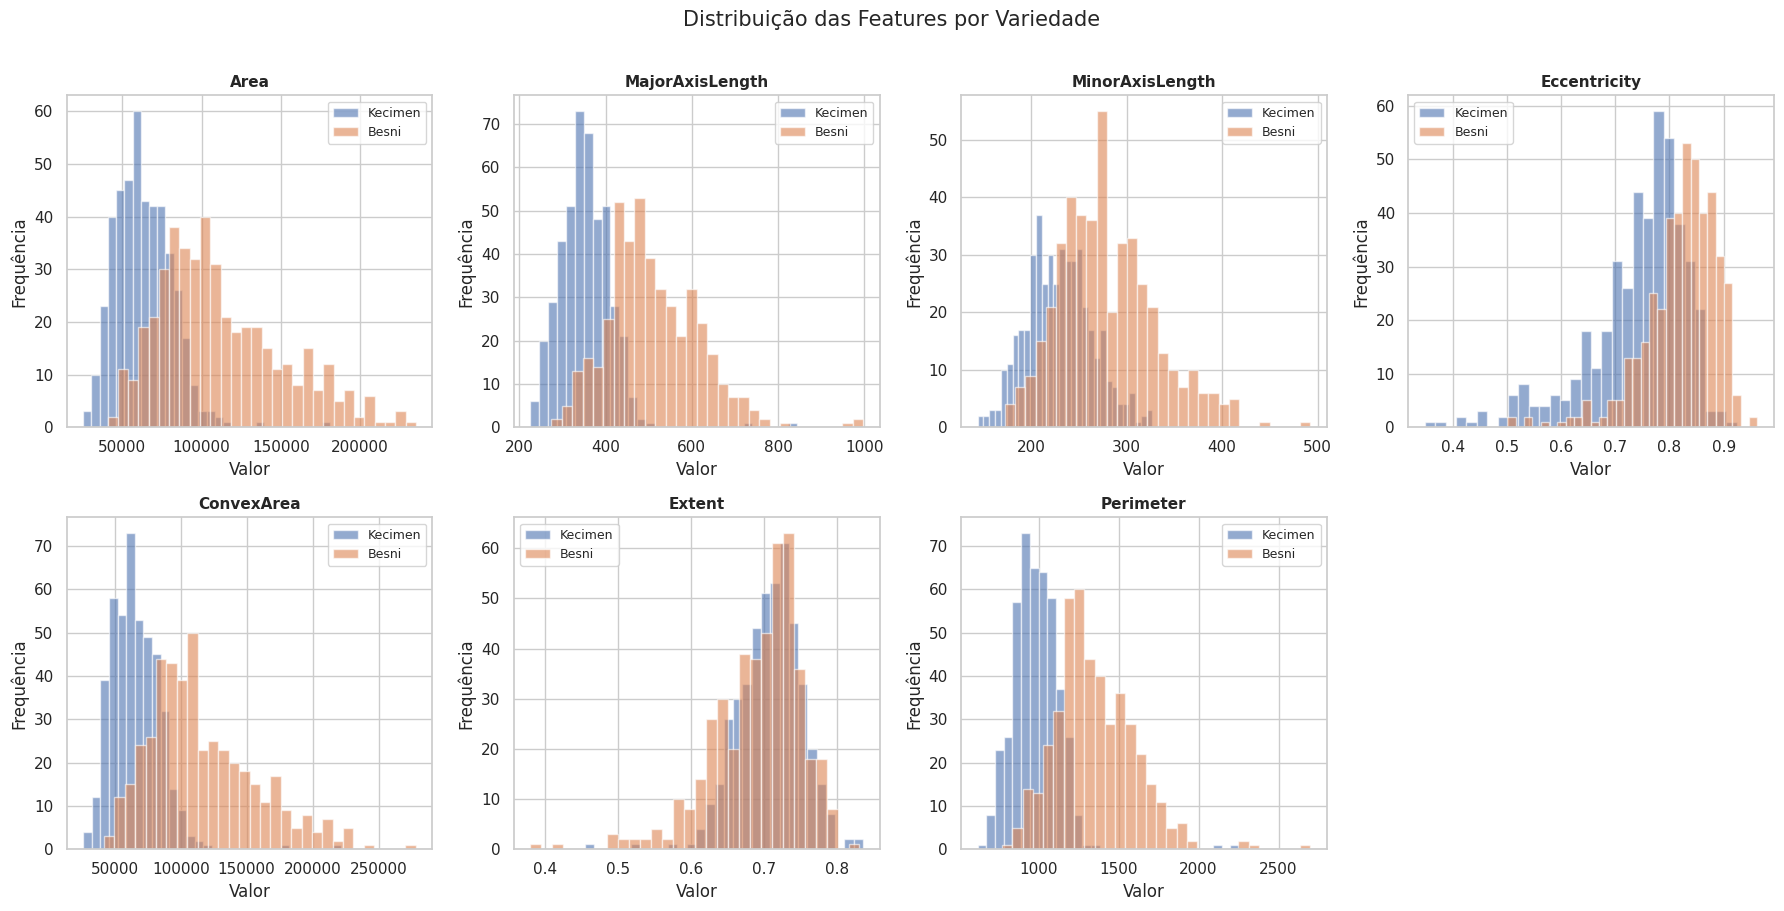

In [11]:
# Explicação: os histogramas mostram a distribuição de frequência
# de cada feature. Ao sobrepor Kecimen e Besni no mesmo gráfico,
# vemos onde as distribuições se separam — regiões de separação
# clara indicam poder discriminativo da feature.

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distribuição das Features por Variedade', fontsize=15, y=1.01)

for idx, feature in enumerate(features):
    ax = axes[idx // 4][idx % 4]

    # Explicação: plotamos um histograma para cada classe
    # alpha=0.6 deixa as barras semitransparentes para enxergar sobreposição
    for classe, cor in cores.items():
        dados = df[df['Class'] == classe][feature]
        ax.hist(
            dados,
            bins=30,           # Explicação: número de barras no histograma
            alpha=0.6,         # Explicação: transparência (0=invisível, 1=opaco)
            color=cor,
            label=classe,
            edgecolor='white'
        )

    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

axes[1][3].set_visible(False)

plt.tight_layout()
plt.show()


In [12]:
# Explicação: outliers são valores muito distantes da maioria
# dos dados. Usamos a regra do IQR (Intervalo Interquartil):
# qualquer valor abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR
# é considerado outlier. Isso é o mesmo critério dos "whiskers"
# nos boxplots.

print("=== Contagem de Outliers por Feature (regra IQR) ===\n")

resultados_outlier = []

for feature in features:
    Q1 = df[feature].quantile(0.25)   # Explicação: primeiro quartil (25%)
    Q3 = df[feature].quantile(0.75)   # Explicação: terceiro quartil (75%)
    IQR = Q3 - Q1                     # Explicação: amplitude interquartil

    # Explicação: limites além dos quais um valor é outlier
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    # Explicação: conta quantos valores estão fora dos limites
    n_outliers = df[(df[feature] < lim_inf) | (df[feature] > lim_sup)].shape[0]
    pct = round(n_outliers / len(df) * 100, 1)

    resultados_outlier.append({
        'Feature': feature,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Limite Inf.': round(lim_inf, 2),
        'Limite Sup.': round(lim_sup, 2),
        'Outliers': n_outliers,
        '% do total': f'{pct}%'
    })

# Explicação: exibe a tabela de outliers de forma organizada
df_outliers = pd.DataFrame(resultados_outlier)
display(df_outliers)

total_outliers = df_outliers['Outliers'].sum()
print(f"\n Total de pontos com pelo menos um outlier: verificar por linha se necessário.")
print(f"   Soma de outliers por coluna: {total_outliers}")
print("\n Como o dataset é pequeno (900 linhas) e os outliers representam")
print("   uma fração pequena, manteremos todos os dados para não perder informação.")
print("   O StandardScaler reduz o impacto de escala, mas não remove outliers.")

=== Contagem de Outliers por Feature (regra IQR) ===



,Feature,Q1,Q3,IQR,Limite Inf.,Limite Sup.,Outliers,% do total
0,Area,59348.00,105028.25,45680.25,-9172.38,173548.62,41,4.6%
1,MajorAxisLength,345.44,494.19,148.74,122.33,717.30,17,1.9%
2,MinorAxisLength,219.11,279.89,60.78,127.94,371.05,26,2.9%
3,Eccentricity,0.74,0.84,0.10,0.59,0.99,43,4.8%
4,ConvexArea,61513.25,108375.75,46862.50,-8780.50,178669.50,42,4.7%
5,Extent,0.67,0.73,0.06,0.57,0.83,21,2.3%
6,Perimeter,966.41,1308.39,341.98,453.44,1821.36,17,1.9%



 Total de pontos com pelo menos um outlier: verificar por linha se necessário.
   Soma de outliers por coluna: 207

 Como o dataset é pequeno (900 linhas) e os outliers representam
   uma fração pequena, manteremos todos os dados para não perder informação.
   O StandardScaler reduz o impacto de escala, mas não remove outliers.


In [13]:
# Explicação: X contém as 7 colunas numéricas que o modelo vai
# usar para aprender. y contém apenas a coluna alvo (Class),
# que é o que queremos prever.

# Explicação: lista com os nomes das 7 features morfológicas
features = ['Area', 'MajorAxisLength', 'MinorAxisLength',
            'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']

X = df[features]   # Explicação: DataFrame com as entradas do modelo
y = df['Class']    # Explicação: Series com os rótulos (Kecimen ou Besni)

print("=== Dimensões de X e y ===")
print(f"X (features): {X.shape}")   # Esperado: (900, 7)
print(f"y (target):   {y.shape}")   # Esperado: (900,)

print("\n=== Distribuição do target ===")
print(y.value_counts())



=== Dimensões de X e y ===
X (features): (900, 7)
y (target):   (900,)

=== Distribuição do target ===
Class
Kecimen    450
Besni      450
Name: count, dtype: int64


In [14]:
# Explicação: importamos a função que divide os dados
from sklearn.model_selection import train_test_split

# Explicação: dividimos os dados em treino (720 amostras) e
# teste (180 amostras).
# - test_size=0.2 → 20% para teste
# - random_state=42 → seed fixa para reprodutibilidade
# - stratify=y → garante que a proporção 50/50 de classes
#   seja mantida tanto no treino quanto no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Explicação: essencial para não enviesar a avaliação
)

print("=== Tamanhos dos conjuntos ===")
print(f"Treino:  {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:   {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

print("\n=== Balanceamento no treino ===")
print(y_train.value_counts())

print("\n=== Balanceamento no teste ===")
print(y_test.value_counts())

# Explicação: verificamos que o stratify funcionou —
# ambos devem ter ~50% de cada classe
print("\n Divisão estratificada: proporção de classes preservada em treino e teste.")


=== Tamanhos dos conjuntos ===
Treino:  720 amostras (80%)
Teste:   180 amostras (20%)

=== Balanceamento no treino ===
Class
Besni      360
Kecimen    360
Name: count, dtype: int64

=== Balanceamento no teste ===
Class
Besni      90
Kecimen    90
Name: count, dtype: int64

 Divisão estratificada: proporção de classes preservada em treino e teste.


In [15]:
# Explicação: o StandardScaler transforma cada feature para
# ter média 0 e desvio padrão 1. Isso é necessário para modelos
# sensíveis à escala como SVM e Regressão Logística, pois sem
# padronização features com valores grandes (Area ~87k) dominam
# features pequenas (Eccentricity ~0.78).

# Regra de ouro: fit APENAS no treino, transform em ambos.
# Se fizermos fit no dataset inteiro, "vazamos" informação do
# teste para o treino — o que seria trapaça na avaliação.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # Explicação: cria o objeto de padronização

# Explicação: .fit_transform() aprende a média e desvio padrão
# do treino e já aplica a transformação
X_train_scaled = scaler.fit_transform(X_train)

# Explicação: .transform() aplica a mesma escala aprendida no treino
# ao conjunto de teste — sem re-aprender nada novo
X_test_scaled = scaler.transform(X_test)

# Explicação: convertemos de volta para DataFrame para facilitar
# visualização e manutenção dos nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features)

print("=== Estatísticas do treino ANTES da padronização ===")
display(X_train.describe().round(2).loc[['mean', 'std']])

print("\n=== Estatísticas do treino APÓS a padronização ===")
display(X_train_scaled.describe().round(2).loc[['mean', 'std']])

# Explicação: após padronização, todas as features devem ter
# média ≈ 0 e desvio padrão ≈ 1
print("\n Padronização aplicada. Agora todas as features estão na mesma escala.")
print("   → X_train_scaled e X_test_scaled prontos para os modelos sensíveis à escala.")
print("   → X_train e X_test (sem escala) serão usados pelo Random Forest.")

=== Estatísticas do treino ANTES da padronização ===


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
mean,88568.85,433.48,255.28,0.78,92006.25,0.70,1171.66
std,39302.47,117.46,49.84,0.09,41154.89,0.05,276.00



=== Estatísticas do treino APÓS a padronização ===


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
mean,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0



 Padronização aplicada. Agora todas as features estão na mesma escala.
   → X_train_scaled e X_test_scaled prontos para os modelos sensíveis à escala.
   → X_train e X_test (sem escala) serão usados pelo Random Forest.


In [16]:
# Explicação: a validação cruzada (cross-validation) divide o
# conjunto de treino em K partes (folds). O modelo é treinado
# K vezes, cada vez usando K-1 folds para treino e 1 fold para
# validação. Isso dá uma estimativa mais robusta do desempenho
# do que uma única divisão.

# Explicação: usamos StratifiedKFold para garantir que cada fold
# mantenha a proporção 50/50 das classes — importante mesmo com
# dataset balanceado para garantir consistência

from sklearn.model_selection import StratifiedKFold

# Explicação: 5 folds com seed fixa para reprodutibilidade
# Cada fold de validação terá 720/5 = 144 amostras
cv = StratifiedKFold(
    n_splits=5,       # Explicação: 5 divisões do treino
    shuffle=True,     # Explicação: embaralha antes de dividir
    random_state=42   # Explicação: seed fixa
)

print("=== Configuração da Validação Cruzada ===")
print(f"Método:     StratifiedKFold")
print(f"K (folds):  5")
print(f"Seed:       42")
print(f"Amostras por fold de validação: ~{X_train.shape[0] // 5}")

# Explicação: mostramos como cada fold divide o treino,
# confirmando que o balanceamento é mantido
print("\n=== Verificação dos folds ===")
for fold, (idx_treino, idx_val) in enumerate(cv.split(X_train, y_train), start=1):
    n_kec = (y_train.iloc[idx_val] == 'Kecimen').sum()
    n_bes = (y_train.iloc[idx_val] == 'Besni').sum()
    print(f"  Fold {fold}: {len(idx_val)} amostras de validação "
          f"→ Kecimen: {n_kec}, Besni: {n_bes}")

print("\n Validação cruzada configurada. O objeto 'cv' será passado")
print("   para todos os modelos na Parte 4.")

=== Configuração da Validação Cruzada ===
Método:     StratifiedKFold
K (folds):  5
Seed:       42
Amostras por fold de validação: ~144

=== Verificação dos folds ===
  Fold 1: 144 amostras de validação → Kecimen: 72, Besni: 72
  Fold 2: 144 amostras de validação → Kecimen: 72, Besni: 72
  Fold 3: 144 amostras de validação → Kecimen: 72, Besni: 72
  Fold 4: 144 amostras de validação → Kecimen: 72, Besni: 72
  Fold 5: 144 amostras de validação → Kecimen: 72, Besni: 72

 Validação cruzada configurada. O objeto 'cv' será passado
   para todos os modelos na Parte 4.


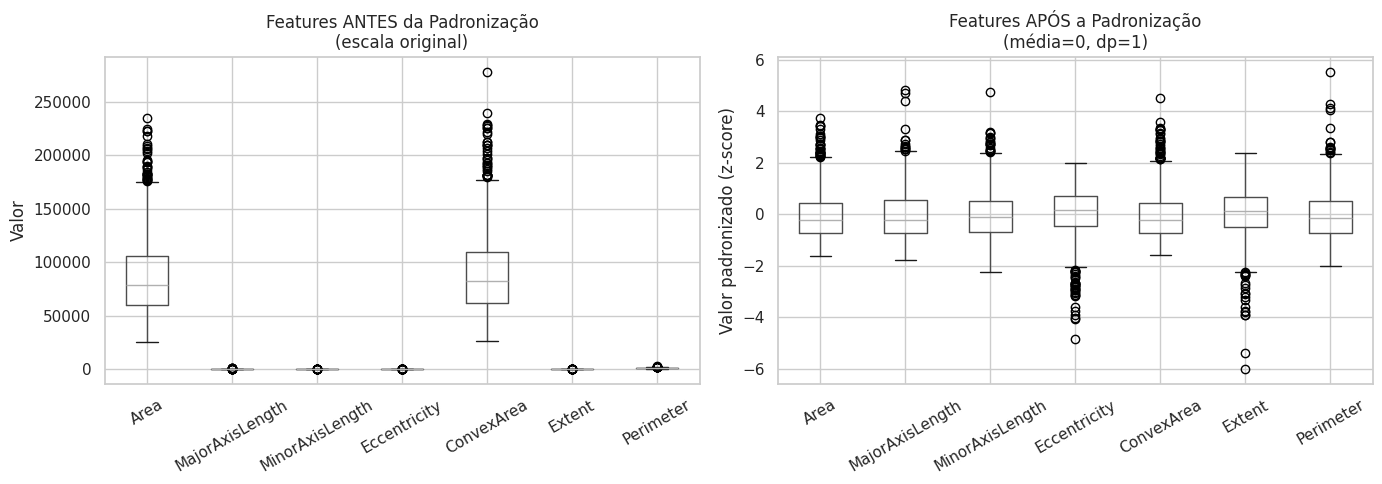


=== Resumo da Preparação ===
Conjunto             Amostras     Features   Padronizado?
-------------------------------------------------------
X_train              720          7          Não (para Random Forest)
X_train_scaled       720          7          Sim (para SVM e LogReg)
X_test               180          7          Não (para Random Forest)
X_test_scaled        180          7          Sim (para SVM e LogReg)

cv                   StratifiedKFold(5 folds, seed=42)


In [17]:
# Explicação: gráfico visual comparando as features antes e
# depois da padronização para facilitar a explicação no notebook

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Explicação: boxplot ANTES da padronização — escala original
X_train.boxplot(ax=axes[0], rot=30)
axes[0].set_title('Features ANTES da Padronização\n(escala original)', fontsize=12)
axes[0].set_ylabel('Valor')

# Explicação: boxplot APÓS a padronização — todas na mesma escala
X_train_scaled.boxplot(ax=axes[1], rot=30)
axes[1].set_title('Features APÓS a Padronização\n(média=0, dp=1)', fontsize=12)
axes[1].set_ylabel('Valor padronizado (z-score)')

plt.tight_layout()
plt.show()

# Explicação: tabela resumo do que foi preparado
print("\n=== Resumo da Preparação ===")
print(f"{'Conjunto':<20} {'Amostras':<12} {'Features':<10} {'Padronizado?'}")
print("-" * 55)
print(f"{'X_train':<20} {X_train.shape[0]:<12} {X_train.shape[1]:<10} Não (para Random Forest)")
print(f"{'X_train_scaled':<20} {X_train_scaled.shape[0]:<12} {X_train_scaled.shape[1]:<10} Sim (para SVM e LogReg)")
print(f"{'X_test':<20} {X_test.shape[0]:<12} {X_test.shape[1]:<10} Não (para Random Forest)")
print(f"{'X_test_scaled':<20} {X_test_scaled.shape[0]:<12} {X_test_scaled.shape[1]:<10} Sim (para SVM e LogReg)")
print(f"\n{'cv':<20} StratifiedKFold(5 folds, seed=42)")

In [18]:
# Explicação: importamos todos os modelos e métricas que usaremos
# nesta parte. Centralizar as importações aqui facilita a leitura.

from sklearn.dummy import DummyClassifier          # Explicação: modelo baseline ingênuo
from sklearn.linear_model import LogisticRegression  # Explicação: modelo linear clássico
from sklearn.ensemble import RandomForestClassifier  # Explicação: ensemble de árvores
from sklearn.svm import SVC                          # Explicação: Support Vector Machine
from sklearn.model_selection import cross_validate   # Explicação: validação cruzada completa
from sklearn.metrics import (
    accuracy_score,       # Explicação: proporção de acertos totais
    f1_score,             # Explicação: média harmônica entre precisão e recall
    precision_score,      # Explicação: dos que previmos como positivo, quantos eram?
    recall_score,         # Explicação: dos positivos reais, quantos capturamos?
    confusion_matrix,     # Explicação: tabela de acertos e erros por classe
    classification_report # Explicação: relatório completo por classe
)

# Explicação: dicionário para guardar os resultados de todos os modelos
# para comparação final
resultados = {}

# Explicação: função auxiliar que roda a validação cruzada de um modelo
# e retorna as métricas médias. Isso evita repetir o mesmo código
# para cada modelo.
def avaliar_modelo(nome, modelo, X_tr, y_tr, cv_obj):
    """
    Roda cross_validate com 5 folds e retorna métricas médias.
    nome    : string com o nome do modelo
    modelo  : objeto sklearn já instanciado
    X_tr    : features de treino (scaled ou não, conforme o modelo)
    y_tr    : target de treino
    cv_obj  : objeto StratifiedKFold
    """

    # Explicação: cross_validate executa o treino e avaliação em cada fold
    # scoring define quais métricas calcular em cada fold
    scores = cross_validate(
        modelo, X_tr, y_tr,
        cv=cv_obj,
        scoring={
            'accuracy':  'accuracy',
            'f1_macro':  'f1_macro',
            'precision': 'precision_macro',
            'recall':    'recall_macro'
        },
        return_train_score=True   # Explicação: também guarda score no treino
                                  # para detectar overfitting
    )

    # Explicação: calculamos a média e desvio padrão de cada métrica
    # ao longo dos 5 folds
    resultado = {
        'Acurácia Val.':    round(scores['test_accuracy'].mean()  * 100, 2),
        'F1-Macro Val.':    round(scores['test_f1_macro'].mean()  * 100, 2),
        'Precisão Val.':    round(scores['test_precision'].mean() * 100, 2),
        'Recall Val.':      round(scores['test_recall'].mean()    * 100, 2),
        'Acurácia Treino':  round(scores['train_accuracy'].mean() * 100, 2),
        'F1 Std (±)':       round(scores['test_f1_macro'].std()   * 100, 2),
    }

    # Explicação: armazenamos no dicionário global para comparação
    resultados[nome] = resultado

    # Explicação: imprimimos um resumo formatado
    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    print(f"  Acurácia  (val): {resultado['Acurácia Val.']:>6.2f}%")
    print(f"  F1-Macro  (val): {resultado['F1-Macro Val.']:>6.2f}%  ± {resultado['F1 Std (±)']:.2f}%")
    print(f"  Precisão  (val): {resultado['Precisão Val.']:>6.2f}%")
    print(f"  Recall    (val): {resultado['Recall Val.']:>6.2f}%")
    print(f"  Acurácia (treino): {resultado['Acurácia Treino']:>6.2f}%")

    # Explicação: diferença treino-validação acima de ~5% pode indicar overfitting
    gap = resultado['Acurácia Treino'] - resultado['Acurácia Val.']
    if gap > 5:
        print(f"   Gap treino-val: {gap:.1f}% → possível overfitting")
    else:
        print(f"  Gap treino-val: {gap:.1f}% → sem sinais de overfitting")

    return scores

print(" Função de avaliação definida. Pronto para modelar!")


 Função de avaliação definida. Pronto para modelar!


In [19]:
# Explicação: o baseline é o ponto de partida mínimo — um modelo
# que não aprende nada, apenas chuta a classe mais frequente.
# Todo modelo real precisa superar o baseline para ter valor.
# Com classes 50/50, esperamos ~50% de acurácia aqui.

print(">>> MODELO 1: Baseline (DummyClassifier)")

baseline = DummyClassifier(
    strategy='most_frequent',  # Explicação: sempre prevê a classe mais comum
    random_state=42
)

# Explicação: usamos X_train sem escala (não importa para o Dummy,
# mas mantemos o padrão)
scores_baseline = avaliar_modelo(
    'Baseline (Dummy)',
    baseline,
    X_train, y_train, cv
)


>>> MODELO 1: Baseline (DummyClassifier)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


  Baseline (Dummy)
  Acurácia  (val):  50.00%
  F1-Macro  (val):  33.33%  ± 0.00%
  Precisão  (val):  25.00%
  Recall    (val):  50.00%
  Acurácia (treino):  50.00%
  Gap treino-val: 0.0% → sem sinais de overfitting


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [20]:
# Explicação: a Regressão Logística é um modelo linear que aprende
# um hiperplano de separação entre as classes. É simples,
# interpretável e serve como segundo baseline "inteligente".
# Requer dados padronizados — usamos X_train_scaled.

print(">>> MODELO 2: Regressão Logística")

logreg = LogisticRegression(
    max_iter=1000,    # Explicação: número máximo de iterações para convergir
    random_state=42,
    C=1.0             # Explicação: inverso da regularização (padrão)
)

scores_logreg = avaliar_modelo(
    'Regressão Logística',
    logreg,
    X_train_scaled, y_train, cv   # Explicação: usa dados padronizados
)

>>> MODELO 2: Regressão Logística

  Regressão Logística
  Acurácia  (val):  86.67%
  F1-Macro  (val):  86.66%  ± 1.95%
  Precisão  (val):  86.76%
  Recall    (val):  86.67%
  Acurácia (treino):  86.49%
  Gap treino-val: -0.2% → sem sinais de overfitting


In [21]:
# Explicação: o Random Forest cria várias árvores de decisão
# treinadas em subamostras aleatórias dos dados e das features,
# e combina as previsões por votação majoritária.
# Vantagens: robusto a outliers, não precisa de padronização,
# fornece importância das features.

print(">>> MODELO 3: Random Forest")

rf = RandomForestClassifier(
    n_estimators=100,   # Explicação: número de árvores na floresta
    random_state=42,
    n_jobs=-1           # Explicação: usa todos os núcleos disponíveis
)

scores_rf = avaliar_modelo(
    'Random Forest',
    rf,
    X_train, y_train, cv   # Explicação: não precisa de padronização
)


>>> MODELO 3: Random Forest

  Random Forest
  Acurácia  (val):  85.69%
  F1-Macro  (val):  85.67%  ± 1.81%
  Precisão  (val):  85.90%
  Recall    (val):  85.69%
  Acurácia (treino): 100.00%
   Gap treino-val: 14.3% → possível overfitting


In [22]:
# Explicação: o SVM encontra o hiperplano que maximiza a margem
# entre as classes. Com kernel RBF (Radial Basis Function),
# consegue separar dados não linearmente separáveis.
# É sensível à escala — usamos X_train_scaled.

print(">>> MODELO 4: SVM (kernel RBF)")

svm = SVC(
    kernel='rbf',      # Explicação: kernel não linear (mais poderoso que linear)
    C=1.0,             # Explicação: parâmetro de regularização
    gamma='scale',     # Explicação: ajuste automático do gamma baseado nos dados
    random_state=42,
    probability=True   # Explicação: habilita estimativas de probabilidade
)

scores_svm = avaliar_modelo(
    'SVM (RBF)',
    svm,
    X_train_scaled, y_train, cv   # Explicação: usa dados padronizados
)

>>> MODELO 4: SVM (kernel RBF)

  SVM (RBF)
  Acurácia  (val):  85.97%
  F1-Macro  (val):  85.93%  ± 1.88%
  Precisão  (val):  86.35%
  Recall    (val):  85.97%
  Acurácia (treino):  87.01%
  Gap treino-val: 1.0% → sem sinais de overfitting



=== TABELA COMPARATIVA — Validação Cruzada (5 folds) ===



,Acurácia Val.,F1-Macro Val.,Precisão Val.,Recall Val.,Acurácia Treino,F1 Std (±)
Regressão Logística,86.67,86.66,86.76,86.67,86.49,1.95
SVM (RBF),85.97,85.93,86.35,85.97,87.01,1.88
Random Forest,85.69,85.67,85.90,85.69,100.00,1.81
Baseline (Dummy),50.00,33.33,25.00,50.00,50.00,0.00


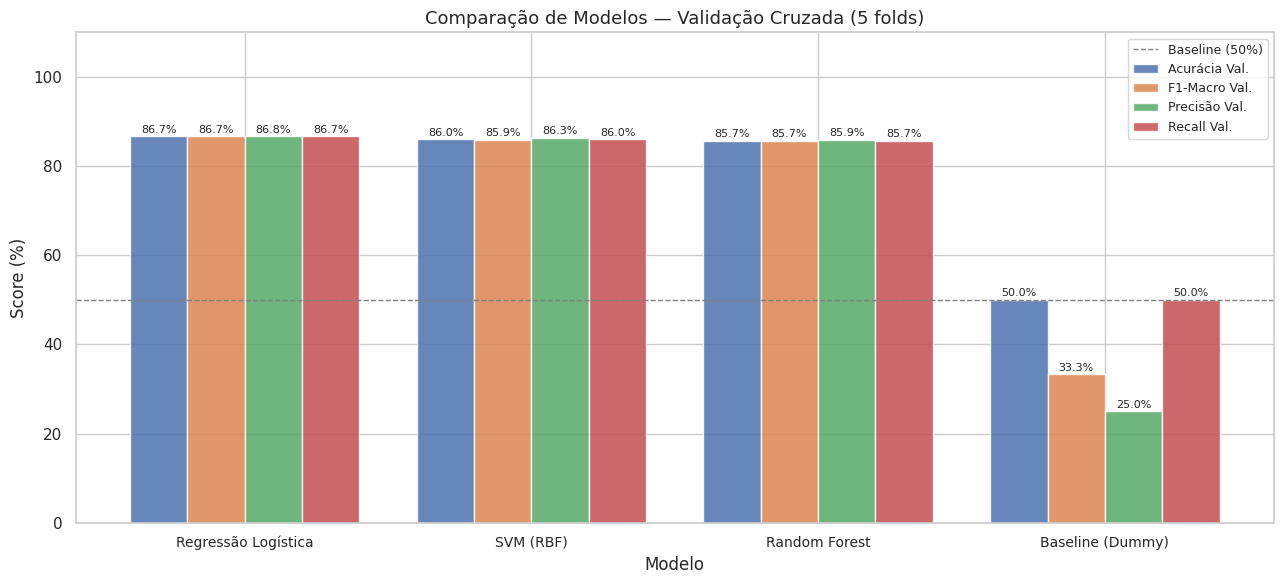


 Melhor modelo na validação cruzada: Regressão Logística
   F1-Macro: 86.66%

→ Este modelo será otimizado na Parte 5 (GridSearchCV).


In [23]:
# Explicação: reunimos todos os resultados em uma tabela única
# para facilitar a comparação visual entre os modelos

print("\n=== TABELA COMPARATIVA — Validação Cruzada (5 folds) ===\n")

# Explicação: convertemos o dicionário de resultados para DataFrame
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values('F1-Macro Val.', ascending=False)
display(df_resultados)

# Explicação: gráfico de barras agrupadas comparando as métricas
# principais de cada modelo
metricas_plot = ['Acurácia Val.', 'F1-Macro Val.', 'Precisão Val.', 'Recall Val.']
modelos = df_resultados.index.tolist()

x = np.arange(len(modelos))   # Explicação: posições no eixo X
largura = 0.2                  # Explicação: largura de cada barra

fig, ax = plt.subplots(figsize=(13, 6))

# Explicação: plotamos uma barra por métrica, deslocadas no eixo X
cores_barras = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for i, (metrica, cor) in enumerate(zip(metricas_plot, cores_barras)):
    valores = df_resultados[metrica].values
    barras = ax.bar(x + i * largura, valores, largura, label=metrica, color=cor, alpha=0.85)

    # Explicação: adiciona o valor em cima de cada barra
    for barra in barras:
        h = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

# Explicação: linha de referência na acurácia do baseline (~50%)
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Baseline (50%)')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparação de Modelos — Validação Cruzada (5 folds)', fontsize=13)
ax.set_xticks(x + largura * 1.5)
ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Explicação: identificamos o melhor modelo pelo F1-Macro na validação
melhor = df_resultados['F1-Macro Val.'].idxmax()
print(f"\n Melhor modelo na validação cruzada: {melhor}")
print(f"   F1-Macro: {df_resultados.loc[melhor, 'F1-Macro Val.']}%")
print("\n→ Este modelo será otimizado na Parte 5 (GridSearchCV).")

In [24]:
# Explicação: GridSearchCV testa todas as combinações de
# hiperparâmetros definidas e escolhe a que dá melhor resultado
# na validação cruzada — de forma automática e reproduzível.

from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')   # Explicação: suprime avisos de convergência

print(" GridSearchCV importado. Iniciando otimização dos modelos...")

 GridSearchCV importado. Iniciando otimização dos modelos...


In [25]:
# Explicação: os principais hiperparâmetros da Regressão Logística são:
# C → controla a regularização (valores menores = mais regularização,
#     reduz overfitting mas pode causar underfitting)
# penalty → tipo de regularização (l2 é o padrão; l1 tende a zerar features)
# solver → algoritmo de otimização interno

print(">>> Otimizando Regressão Logística...")

param_grid_logreg = {
    'C':       [0.01, 0.1, 1, 10, 100],   # Explicação: força de regularização
    'penalty': ['l1', 'l2'],               # Explicação: tipo de penalidade
    'solver':  ['liblinear']               # Explicação: único solver que suporta l1 e l2
}

# Explicação: GridSearchCV testa todas as combinações (5×2×1 = 10 combinações)
# usando a validação cruzada estratificada de 5 folds que já definimos
grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_logreg,
    cv=cv,                    # Explicação: reutiliza o mesmo cv da Parte 3
    scoring='f1_macro',       # Explicação: métrica de seleção do melhor modelo
    n_jobs=-1,                # Explicação: paraleliza em todos os núcleos
    return_train_score=True
)

grid_logreg.fit(X_train_scaled, y_train)

print(f"\n  Melhores hiperparâmetros: {grid_logreg.best_params_}")
print(f"  Melhor F1-Macro (val):    {grid_logreg.best_score_*100:.2f}%")
print(f"  F1-Macro antes:           86.66%")
ganho_lr = grid_logreg.best_score_*100 - 86.66
print(f"  Ganho com otimização:     {ganho_lr:+.2f}%")

>>> Otimizando Regressão Logística...

  Melhores hiperparâmetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Melhor F1-Macro (val):    86.79%
  F1-Macro antes:           86.66%
  Ganho com otimização:     +0.13%


In [26]:
# Explicação: os principais hiperparâmetros do Random Forest são:
# n_estimators → número de árvores (mais árvores = mais estável, mais lento)
# max_depth    → profundidade máxima das árvores (controla overfitting)
# min_samples_split → mínimo de amostras para dividir um nó
# max_features → número de features consideradas em cada divisão

print("\n>>> Otimizando Random Forest...")

param_grid_rf = {
    'n_estimators':    [100, 200, 300],     # Explicação: quantidade de árvores
    'max_depth':       [None, 10, 20, 30],  # Explicação: None = sem limite
    'min_samples_split': [2, 5, 10],        # Explicação: mínimo para dividir nó
    'max_features':    ['sqrt', 'log2']     # Explicação: features por divisão
}

# Explicação: 3×4×3×2 = 72 combinações × 5 folds = 360 treinos
# Pode demorar 1-2 minutos
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

print(f"\n  Melhores hiperparâmetros: {grid_rf.best_params_}")
print(f"  Melhor F1-Macro (val):    {grid_rf.best_score_*100:.2f}%")
print(f"  F1-Macro antes:           85.67%")
ganho_rf = grid_rf.best_score_*100 - 85.67
print(f"  Ganho com otimização:     {ganho_rf:+.2f}%")


>>> Otimizando Random Forest...

  Melhores hiperparâmetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
  Melhor F1-Macro (val):    86.37%
  F1-Macro antes:           85.67%
  Ganho com otimização:     +0.70%


In [27]:
# Explicação: os principais hiperparâmetros do SVM com kernel RBF são:
# C     → regularização (maior C = menos margem, mais ajuste aos dados)
# gamma → raio de influência de cada ponto de suporte
#         'scale' = 1/(n_features * X.var()), 'auto' = 1/n_features

print("\n>>> Otimizando SVM (RBF)...")

param_grid_svm = {
    'C':     [0.1, 1, 10, 100],              # Explicação: penalidade por erros
    'gamma': ['scale', 'auto', 0.001, 0.01]  # Explicação: raio do kernel RBF
}

# Explicação: 4×4 = 16 combinações × 5 folds = 80 treinos
grid_svm = GridSearchCV(
    SVC(kernel='rbf', random_state=42, probability=True),
    param_grid_svm,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_svm.fit(X_train_scaled, y_train)

print(f"\n  Melhores hiperparâmetros: {grid_svm.best_params_}")
print(f"  Melhor F1-Macro (val):    {grid_svm.best_score_*100:.2f}%")
print(f"  F1-Macro antes:           85.93%")
ganho_svm = grid_svm.best_score_*100 - 85.93
print(f"  Ganho com otimização:     {ganho_svm:+.2f}%")



>>> Otimizando SVM (RBF)...

  Melhores hiperparâmetros: {'C': 0.1, 'gamma': 'scale'}
  Melhor F1-Macro (val):    87.06%
  F1-Macro antes:           85.93%
  Ganho com otimização:     +1.13%



=== COMPARAÇÃO: Antes × Depois da Otimização ===



,F1 Antes (%),F1 Depois (%),Melhores Params,Ganho (%)
SVM (RBF),85.93,87.06,"{'C': 0.1, 'gamma': 'scale'}",1.13
Regressão Logística,86.66,86.79,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.13
Random Forest,85.67,86.37,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.7



 Melhor modelo após otimização: SVM (RBF)
   F1-Macro (validação): 87.06%


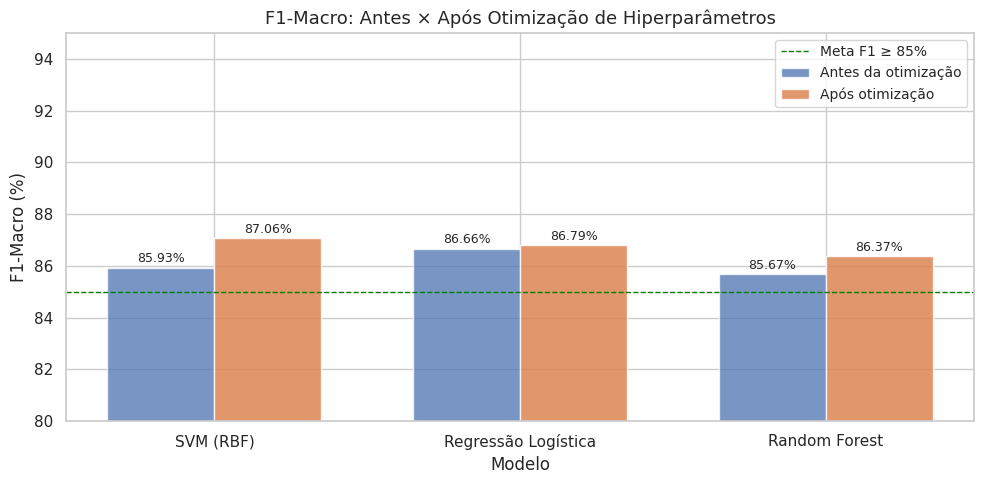


→ O modelo 'SVM (RBF)' com os melhores hiperparâmetros
  será treinado com TODO o conjunto de treino e avaliado no teste na Parte 6.


In [28]:
# Explicação: comparamos os resultados antes e depois da otimização
# para justificar as escolhas de hiperparâmetros no relatório

print("\n=== COMPARAÇÃO: Antes × Depois da Otimização ===\n")

dados_comparacao = {
    'Regressão Logística': {
        'F1 Antes (%)': 86.66,
        'F1 Depois (%)': round(grid_logreg.best_score_ * 100, 2),
        'Melhores Params': str(grid_logreg.best_params_)
    },
    'Random Forest': {
        'F1 Antes (%)': 85.67,
        'F1 Depois (%)': round(grid_rf.best_score_ * 100, 2),
        'Melhores Params': str(grid_rf.best_params_)
    },
    'SVM (RBF)': {
        'F1 Antes (%)': 85.93,
        'F1 Depois (%)': round(grid_svm.best_score_ * 100, 2),
        'Melhores Params': str(grid_svm.best_params_)
    }
}

df_comparacao = pd.DataFrame(dados_comparacao).T
df_comparacao['Ganho (%)'] = (df_comparacao['F1 Depois (%)'] - df_comparacao['F1 Antes (%)']).round(2)
df_comparacao = df_comparacao.sort_values('F1 Depois (%)', ascending=False)
display(df_comparacao)

# Explicação: identificamos o melhor modelo otimizado
melhor_otimizado = df_comparacao['F1 Depois (%)'].idxmax()
melhor_score = df_comparacao['F1 Depois (%)'].max()

print(f"\n Melhor modelo após otimização: {melhor_otimizado}")
print(f"   F1-Macro (validação): {melhor_score}%")

# Explicação: gráfico comparando F1 antes e depois por modelo
fig, ax = plt.subplots(figsize=(10, 5))

modelos_opt = df_comparacao.index.tolist()
x = np.arange(len(modelos_opt))
largura = 0.35

barras_antes = ax.bar(x - largura/2,
                      df_comparacao['F1 Antes (%)'],
                      largura, label='Antes da otimização',
                      color='#4C72B0', alpha=0.75)

barras_depois = ax.bar(x + largura/2,
                       df_comparacao['F1 Depois (%)'],
                       largura, label='Após otimização',
                       color='#DD8452', alpha=0.85)

# Explicação: rótulos em cima de cada barra
for barra in list(barras_antes) + list(barras_depois):
    h = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, h + 0.1,
            f'{h:.2f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(y=85, color='green', linestyle='--', linewidth=1,
           label='Meta F1 ≥ 85%')
ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('F1-Macro (%)', fontsize=12)
ax.set_title('F1-Macro: Antes × Após Otimização de Hiperparâmetros', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(modelos_opt, fontsize=11)
ax.set_ylim(80, 95)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n→ O modelo '{melhor_otimizado}' com os melhores hiperparâmetros")
print(f"  será treinado com TODO o conjunto de treino e avaliado no teste na Parte 6.")

In [29]:
# Explicação: agora que escolhemos o SVM com os melhores
# hiperparâmetros encontrados pelo GridSearchCV, treinamos
# com TODO o conjunto de treino (720 amostras) — não apenas
# com 4/5 dos folds como na validação cruzada.
# Isso aproveita ao máximo os dados disponíveis.

# Explicação: grid_svm.best_estimator_ é o modelo SVM já
# configurado com os melhores hiperparâmetros — não precisamos
# recriar manualmente
modelo_final = grid_svm.best_estimator_

print("=== Modelo Final Selecionado ===")
print(f"Algoritmo:         SVM (kernel RBF)")
print(f"Hiperparâmetros:   {grid_svm.best_params_}")
print(f"F1-Macro (val CV): {grid_svm.best_score_*100:.2f}%")
print(f"\nTreinando com todo o conjunto de treino ({X_train_scaled.shape[0]} amostras)...")

# Explicação: .fit() treina o modelo com todos os dados de treino
modelo_final.fit(X_train_scaled, y_train)

print(" Modelo final treinado!")

=== Modelo Final Selecionado ===
Algoritmo:         SVM (kernel RBF)
Hiperparâmetros:   {'C': 0.1, 'gamma': 'scale'}
F1-Macro (val CV): 87.06%

Treinando com todo o conjunto de treino (720 amostras)...
 Modelo final treinado!


In [30]:
# Explicação: agora usamos o conjunto de teste — dados que o
# modelo NUNCA viu durante treino ou validação.
# Esta é a avaliação honesta do desempenho real do modelo.

# Explicação: .predict() gera as classes previstas (Kecimen ou Besni)
y_pred = modelo_final.predict(X_test_scaled)

# Explicação: .predict_proba() retorna a probabilidade de cada classe
# útil para análises mais detalhadas
y_proba = modelo_final.predict_proba(X_test_scaled)

print("=== Primeiras 10 predições vs. valores reais ===")
comparacao = pd.DataFrame({
    'Real':     y_test.values[:10],
    'Previsto': y_pred[:10],
    'Prob Besni (%)':   (y_proba[:10, 0] * 100).round(1),
    'Prob Kecimen (%)': (y_proba[:10, 1] * 100).round(1)
})
display(comparacao)

=== Primeiras 10 predições vs. valores reais ===


,Real,Previsto,Prob Besni (%),Prob Kecimen (%)
0,Besni,Kecimen,49.5,50.5
1,Besni,Besni,95.3,4.7
2,Besni,Besni,95.1,4.9
3,Kecimen,Kecimen,11.4,88.6
4,Besni,Besni,87.6,12.4
5,Kecimen,Kecimen,16.9,83.1
6,Besni,Besni,94.5,5.5
7,Kecimen,Kecimen,5.3,94.7
8,Kecimen,Kecimen,6.4,93.6
9,Kecimen,Kecimen,13.2,86.8


In [31]:
# Explicação: calculamos todas as métricas relevantes no conjunto
# de teste para comparar com o que vimos na validação cruzada.
# Se os valores forem próximos, o modelo generaliza bem.

acuracia  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='macro')
precisao  = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')

print("=== Métricas no Conjunto de Teste ===\n")
print(f"  Acurácia:  {acuracia*100:.2f}%")
print(f"  F1-Macro:  {f1*100:.2f}%   (meta: ≥ 85%)")
print(f"  Precisão:  {precisao*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")

print("\n=== Comparação: Validação CV × Teste Final ===")
print(f"  F1-Macro (validação CV): {grid_svm.best_score_*100:.2f}%")
print(f"  F1-Macro (teste final):  {f1*100:.2f}%")
gap_final = abs(grid_svm.best_score_*100 - f1*100)
print(f"  Diferença:               {gap_final:.2f}%")

if gap_final < 3:
    print("\n   Modelo generaliza bem — sem sinais de overfitting.")
else:
    print("\n    Gap relevante — possível overfitting.")

# Explicação: verificação da meta estabelecida na Etapa 1
if f1 >= 0.85:
    print(f"\n   Meta F1-Macro ≥ 85% ATINGIDA! ({f1*100:.2f}%)")
else:
    print(f"\n   Meta F1-Macro ≥ 85% não atingida ({f1*100:.2f}%)")

=== Métricas no Conjunto de Teste ===

  Acurácia:  87.22%
  F1-Macro:  87.16%   (meta: ≥ 85%)
  Precisão:  88.02%
  Recall:    87.22%

=== Comparação: Validação CV × Teste Final ===
  F1-Macro (validação CV): 87.06%
  F1-Macro (teste final):  87.16%
  Diferença:               0.09%

   Modelo generaliza bem — sem sinais de overfitting.

   Meta F1-Macro ≥ 85% ATINGIDA! (87.16%)


In [32]:
# Explicação: o classification_report mostra precisão, recall e
# F1 separados por classe (Besni e Kecimen), além das médias.
# Isso revela se o modelo performa melhor em uma classe do que outra.

print("=== Relatório de Classificação por Classe ===\n")
print(classification_report(y_test, y_pred, target_names=['Besni', 'Kecimen']))

=== Relatório de Classificação por Classe ===

              precision    recall  f1-score   support

       Besni       0.94      0.80      0.86        90
     Kecimen       0.83      0.94      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



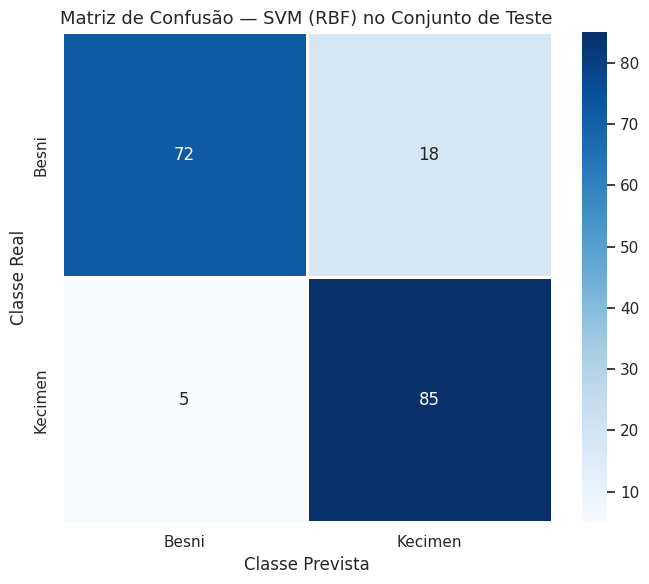


  Besni  → Besni   (acerto): 72
  Besni  → Kecimen (erro):   18
  Kecimen → Kecimen (acerto): 85
  Kecimen → Besni  (erro):   5

  Total de erros: 23 de 180 amostras (12.8%)


In [33]:
# Explicação: a matriz de confusão mostra quantas amostras foram
# classificadas corretamente e onde o modelo errou:
# - Diagonal principal = acertos
# - Fora da diagonal = erros (Besni classificada como Kecimen, e vice-versa)

cm = confusion_matrix(y_test, y_pred, labels=['Besni', 'Kecimen'])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,          # Explicação: mostra os números nas células
    fmt='d',             # Explicação: formato inteiro
    cmap='Blues',        # Explicação: escala de azuis
    xticklabels=['Besni', 'Kecimen'],
    yticklabels=['Besni', 'Kecimen'],
    linewidths=1,
    ax=ax
)
ax.set_xlabel('Classe Prevista', fontsize=12)
ax.set_ylabel('Classe Real', fontsize=12)
ax.set_title('Matriz de Confusão — SVM (RBF) no Conjunto de Teste', fontsize=13)
plt.tight_layout()
plt.show()

# Explicação: interpretação dos quadrantes da matriz
vp_besni  = cm[0, 0]   # Besni prevista como Besni (correto)
fp_besni  = cm[1, 0]   # Kecimen prevista como Besni (erro)
fn_besni  = cm[0, 1]   # Besni prevista como Kecimen (erro)
vp_kec    = cm[1, 1]   # Kecimen prevista como Kecimen (correto)

print(f"\n  Besni  → Besni   (acerto): {vp_besni}")
print(f"  Besni  → Kecimen (erro):   {fn_besni}")
print(f"  Kecimen → Kecimen (acerto): {vp_kec}")
print(f"  Kecimen → Besni  (erro):   {fp_besni}")
total_erros = fn_besni + fp_besni
print(f"\n  Total de erros: {total_erros} de {len(y_test)} amostras ({total_erros/len(y_test)*100:.1f}%)")

In [34]:
# Explicação: para enriquecer a análise, avaliamos também os outros
# modelos otimizados no conjunto de teste — isso é informativo para
# o relatório, mas a decisão já foi tomada com base na validação CV.

print("=== Comparação de Todos os Modelos no Conjunto de Teste ===\n")

modelos_finais = {
    'Regressão Logística': (grid_logreg.best_estimator_, X_test_scaled),
    'Random Forest':       (grid_rf.best_estimator_,    X_test),
    'SVM (RBF)':           (grid_svm.best_estimator_,   X_test_scaled),
}

linhas = []
for nome, (mod, X_tst) in modelos_finais.items():
    # Explicação: treinamos cada modelo com todo o treino antes de avaliar
    if nome == 'Random Forest':
        mod.fit(X_train, y_train)
    else:
        mod.fit(X_train_scaled, y_train)

    pred = mod.predict(X_tst)
    linhas.append({
        'Modelo':      nome,
        'Acurácia (%)': round(accuracy_score(y_test, pred) * 100, 2),
        'F1-Macro (%)': round(f1_score(y_test, pred, average='macro') * 100, 2),
        'Precisão (%)': round(precision_score(y_test, pred, average='macro') * 100, 2),
        'Recall (%)':   round(recall_score(y_test, pred, average='macro') * 100, 2),
    })

df_teste_final = pd.DataFrame(linhas).set_index('Modelo')
df_teste_final = df_teste_final.sort_values('F1-Macro (%)', ascending=False)
display(df_teste_final)

melhor_teste = df_teste_final['F1-Macro (%)'].idxmax()
print(f"\n Melhor modelo no teste: {melhor_teste}")
print(f"   F1-Macro: {df_teste_final.loc[melhor_teste, 'F1-Macro (%)']:.2f}%")
print("\n→ Próximo passo: Parte 7 — Cartas de Controle CEP")

=== Comparação de Todos os Modelos no Conjunto de Teste ===



,Acurácia (%),F1-Macro (%),Precisão (%),Recall (%)
Modelo,,,,
Regressão Logística,87.78,87.74,88.25,87.78
Random Forest,87.78,87.70,88.71,87.78
SVM (RBF),87.22,87.16,88.02,87.22



 Melhor modelo no teste: Regressão Logística
   F1-Macro: 87.74%

→ Próximo passo: Parte 7 — Cartas de Controle CEP


In [35]:
# Explicação: dividimos o conjunto de teste (180 amostras) em
# lotes sequenciais, como se fossem chegando na linha de produção.
# Cada lote representa uma inspeção periódica — por exemplo,
# a cada N grãos inspecionados pela câmera.

TAMANHO_LOTE = 10   # Explicação: 10 grãos por lote de inspeção
                    # (comum em planos de amostragem industriais)

# Explicação: resetamos os índices do conjunto de teste para
# facilitar o fatiamento em lotes
X_teste_reset = X_test.reset_index(drop=True)
X_teste_scaled_reset = X_test_scaled.reset_index(drop=True)
y_teste_reset = y_test.reset_index(drop=True)

# Explicação: calculamos quantos lotes completos conseguimos formar
n_lotes = len(X_teste_reset) // TAMANHO_LOTE
print(f"Amostras no teste: {len(X_teste_reset)}")
print(f"Tamanho do lote:   {TAMANHO_LOTE} grãos")
print(f"Lotes completos:   {n_lotes}")

# Explicação: listas para guardar os valores de cada lote
medias_lote   = []   # média de cada feature por lote (para X-barra)
amplitudes_lote = [] # amplitude (max-min) de cada feature por lote (para R)
prop_nc_lote  = []   # proporção de não conformes por lote (para carta p)

for i in range(n_lotes):
    # Explicação: fatia as amostras do lote i
    inicio = i * TAMANHO_LOTE
    fim    = inicio + TAMANHO_LOTE

    lote_X        = X_teste_reset.iloc[inicio:fim]
    lote_X_scaled = X_teste_scaled_reset.iloc[inicio:fim]
    lote_y        = y_teste_reset.iloc[inicio:fim]

    # Explicação: média de cada feature no lote (para carta X-barra)
    medias_lote.append(lote_X.mean())

    # Explicação: amplitude = máximo - mínimo de cada feature no lote
    # (para carta R — mede a variação interna do lote)
    amplitudes_lote.append(lote_X.max() - lote_X.min())

    # Explicação: o modelo prevê a variedade de cada grão do lote
    # Um grão é "não conforme" se a previsão não bate com a variedade
    # esperada para aquele lote. Como os grãos vêm misturados no teste,
    # consideramos como "não conforme" qualquer grão classificado como
    # Besni num lote onde a maioria é Kecimen, e vice-versa.
    previsoes = modelo_final.predict(lote_X_scaled)
    classe_predominante = lote_y.mode()[0]
    n_nc = (previsoes != classe_predominante).sum()
    prop_nc_lote.append(n_nc / TAMANHO_LOTE)

# Explicação: convertemos as listas para DataFrames
df_medias     = pd.DataFrame(medias_lote,     columns=features)
df_amplitudes = pd.DataFrame(amplitudes_lote, columns=features)
df_prop_nc    = pd.Series(prop_nc_lote, name='prop_nc')

print(f"\n {n_lotes} lotes processados!")
print(f"   df_medias:     {df_medias.shape}")
print(f"   df_amplitudes: {df_amplitudes.shape}")
print(f"   prop_nc média: {df_prop_nc.mean()*100:.1f}%")

Amostras no teste: 180
Tamanho do lote:   10 grãos
Lotes completos:   18

 18 lotes processados!
   df_medias:     (18, 7)
   df_amplitudes: (18, 7)
   prop_nc média: 42.8%


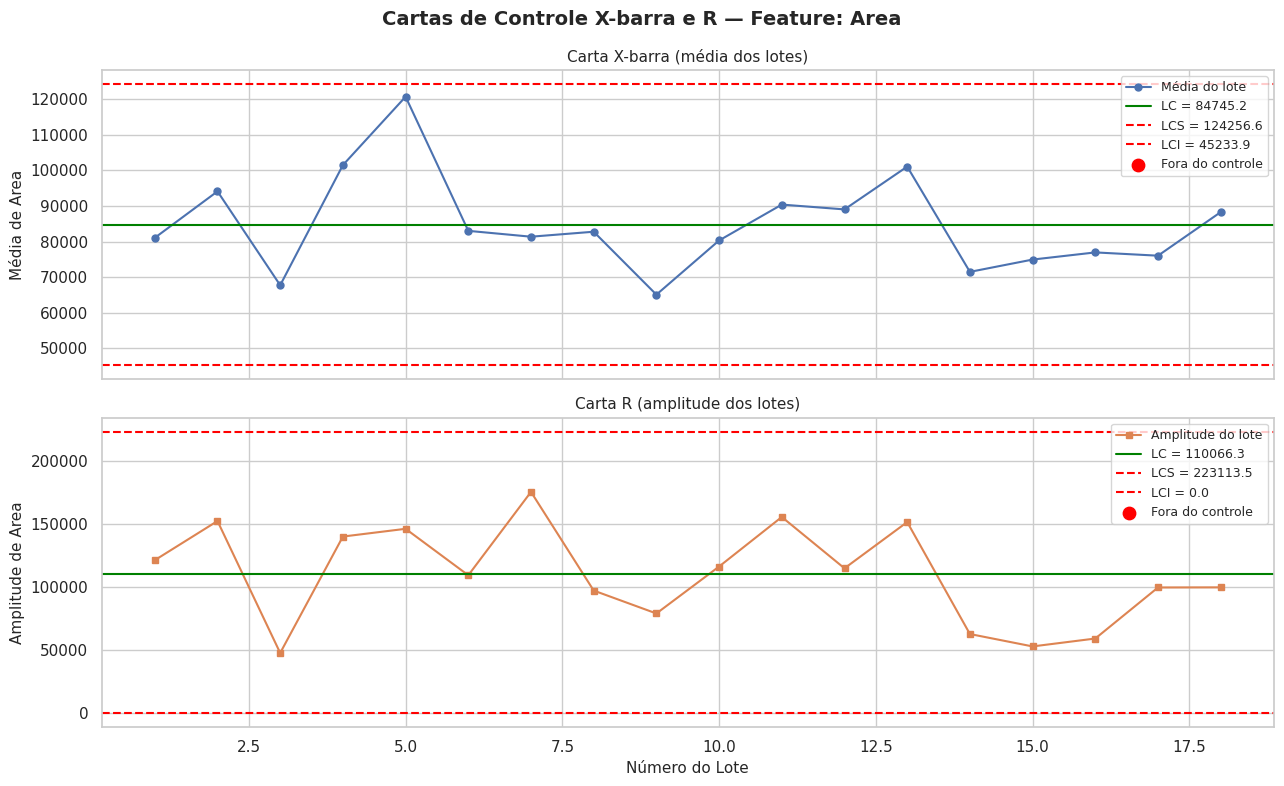


  [Area] X-barra — Pontos fora: 0 de 18 lotes
  [Area] Carta R  — Pontos fora: 0 de 18 lotes


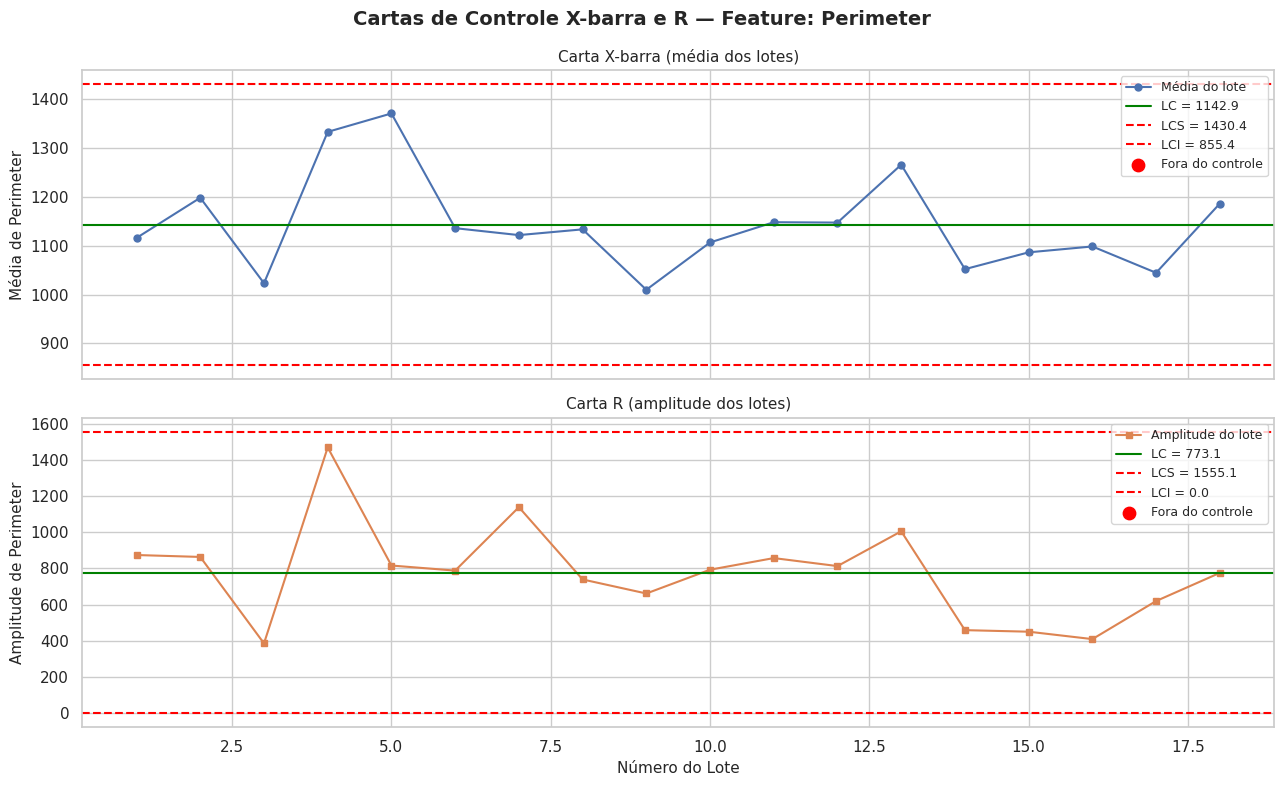


  [Perimeter] X-barra — Pontos fora: 0 de 18 lotes
  [Perimeter] Carta R  — Pontos fora: 0 de 18 lotes


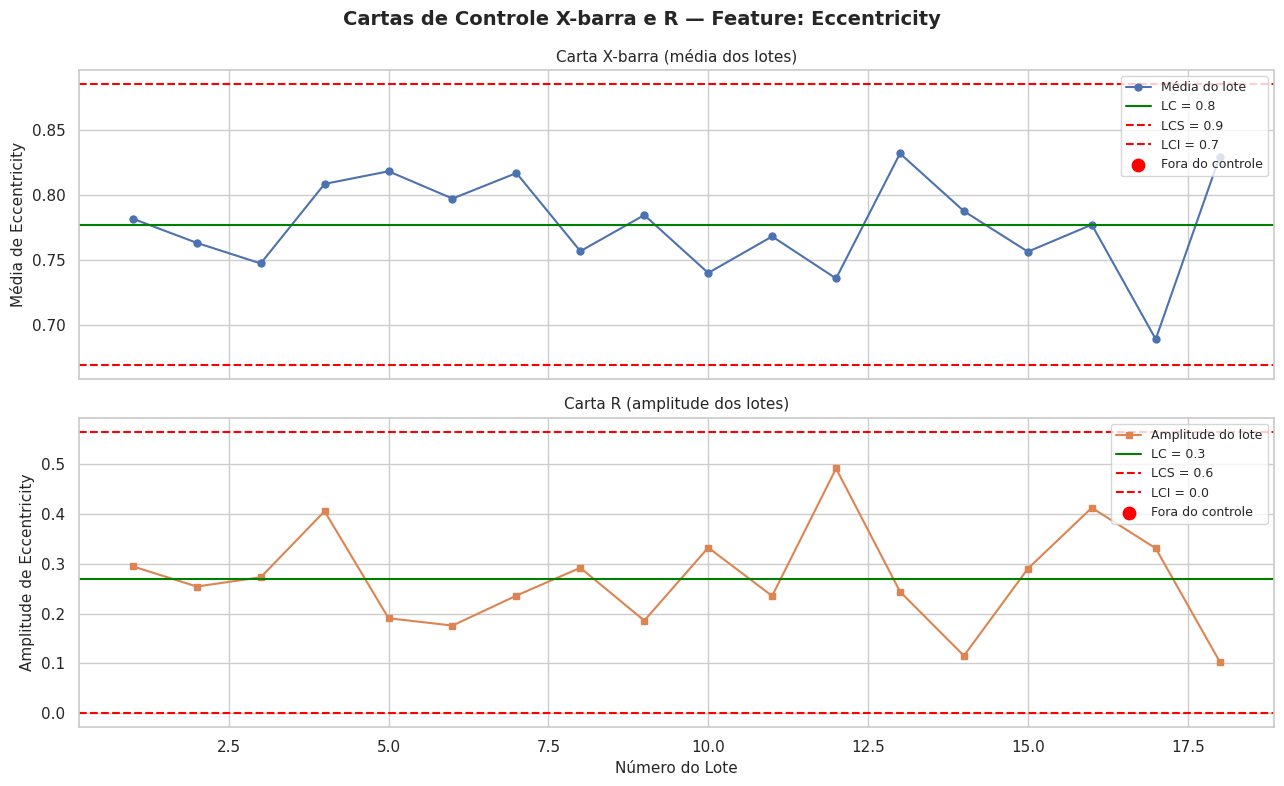


  [Eccentricity] X-barra — Pontos fora: 0 de 18 lotes
  [Eccentricity] Carta R  — Pontos fora: 0 de 18 lotes


In [36]:
# Explicação: plotamos as cartas X-barra e R para a feature
# mais discriminativa — Area — que mostrou maior separação
# entre as variedades na EDA.
# Os limites de controle são calculados como ±3 desvios padrão
# da média dos lotes (método da fase I do CEP).

def plotar_carta_xbarra_R(feature, df_med, df_amp):
    """
    Plota as cartas X-barra e R para uma feature específica.
    Limites: ±3σ sobre a distribuição das médias/amplitudes dos lotes.
    """

    medias  = df_med[feature].values
    ampls   = df_amp[feature].values
    lotes   = np.arange(1, len(medias) + 1)

    # Explicação: linha central = média das médias dos lotes
    xbarra_bar = medias.mean()
    # Explicação: limites de controle = média ± 3 desvios padrão das médias
    xbarra_lcs = xbarra_bar + 3 * medias.std()
    xbarra_lci = xbarra_bar - 3 * medias.std()

    # Explicação: para a carta R: linha central = média das amplitudes
    R_bar  = ampls.mean()
    R_lcs  = R_bar + 3 * ampls.std()
    R_lci  = max(0, R_bar - 3 * ampls.std())  # R não pode ser negativo

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    fig.suptitle(f'Cartas de Controle X-barra e R — Feature: {feature}',
                 fontsize=14, fontweight='bold')

    # --- Carta X-barra ---
    ax1.plot(lotes, medias, 'o-', color='#4C72B0', linewidth=1.5,
             markersize=5, label='Média do lote')
    ax1.axhline(xbarra_bar, color='green',  linewidth=1.5,
                linestyle='-',  label=f'LC = {xbarra_bar:.1f}')
    ax1.axhline(xbarra_lcs, color='red',    linewidth=1.5,
                linestyle='--', label=f'LCS = {xbarra_lcs:.1f}')
    ax1.axhline(xbarra_lci, color='red',    linewidth=1.5,
                linestyle='--', label=f'LCI = {xbarra_lci:.1f}')

    # Explicação: destaca pontos fora dos limites em vermelho
    fora_xbarra = (medias > xbarra_lcs) | (medias < xbarra_lci)
    ax1.scatter(lotes[fora_xbarra], medias[fora_xbarra],
                color='red', zorder=5, s=80, label='Fora do controle')

    ax1.set_ylabel(f'Média de {feature}', fontsize=11)
    ax1.legend(fontsize=9, loc='upper right')
    ax1.set_title('Carta X-barra (média dos lotes)', fontsize=11)

    # --- Carta R ---
    ax2.plot(lotes, ampls, 's-', color='#DD8452', linewidth=1.5,
             markersize=5, label='Amplitude do lote')
    ax2.axhline(R_bar,  color='green', linewidth=1.5,
                linestyle='-',  label=f'LC = {R_bar:.1f}')
    ax2.axhline(R_lcs,  color='red',   linewidth=1.5,
                linestyle='--', label=f'LCS = {R_lcs:.1f}')
    ax2.axhline(R_lci,  color='red',   linewidth=1.5,
                linestyle='--', label=f'LCI = {R_lci:.1f}')

    fora_R = (ampls > R_lcs) | (ampls < R_lci)
    ax2.scatter(lotes[fora_R], ampls[fora_R],
                color='red', zorder=5, s=80, label='Fora do controle')

    ax2.set_xlabel('Número do Lote', fontsize=11)
    ax2.set_ylabel(f'Amplitude de {feature}', fontsize=11)
    ax2.legend(fontsize=9, loc='upper right')
    ax2.set_title('Carta R (amplitude dos lotes)', fontsize=11)

    plt.tight_layout()
    plt.show()

    # Explicação: resumo dos pontos fora de controle
    print(f"\n  [{feature}] X-barra — Pontos fora: {fora_xbarra.sum()} "
          f"de {len(lotes)} lotes")
    print(f"  [{feature}] Carta R  — Pontos fora: {fora_R.sum()} "
          f"de {len(lotes)} lotes")

# Explicação: plotamos as cartas para as 3 features mais relevantes
for feat in ['Area', 'Perimeter', 'Eccentricity']:
    plotar_carta_xbarra_R(feat, df_medias, df_amplitudes)

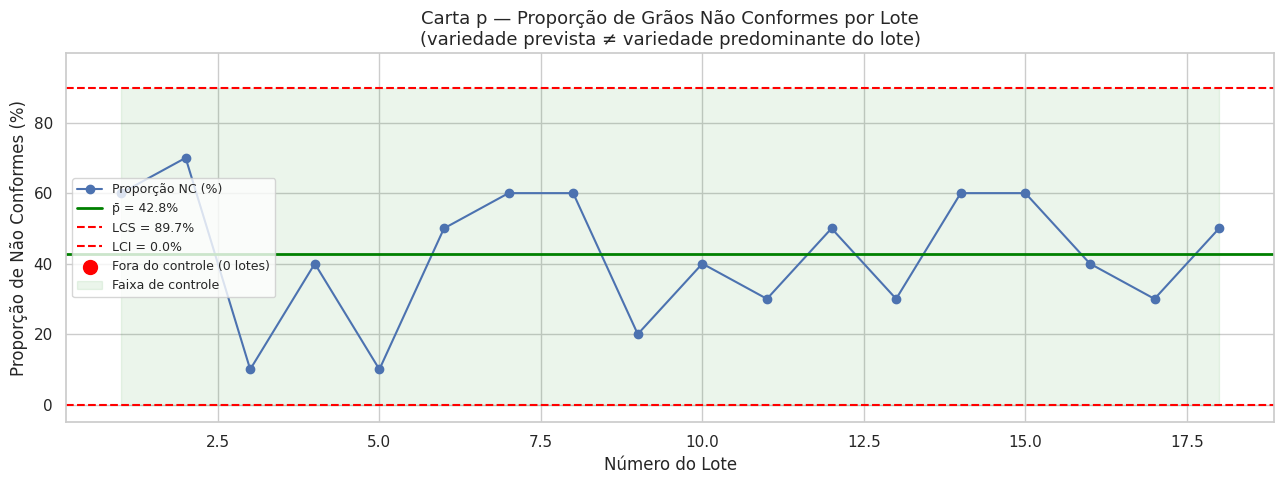


=== Resumo da Carta p ===
  Proporção média de NC (p̄): 42.8%
  LCS:                        89.7%
  LCI:                        0.0%
  Lotes fora de controle:     0 de 18

  Processo sob controle: nenhum lote com proporção anormal de NC.


In [37]:
# Explicação: a carta p monitora a proporção de itens não conformes
# em cada lote. No contexto do projeto, um item não conforme é um
# grão classificado pelo modelo como a variedade errada para aquele lote.
# Limites 3-sigma: p̄ ± 3 * sqrt(p̄*(1-p̄)/n)

prop_nc = df_prop_nc.values
lotes   = np.arange(1, len(prop_nc) + 1)
n       = TAMANHO_LOTE   # Explicação: tamanho de cada lote

# Explicação: p̄ = média das proporções de não conformes
p_barra = prop_nc.mean()

# Explicação: desvio padrão da proporção (fórmula binomial)
sigma_p = np.sqrt(p_barra * (1 - p_barra) / n)

# Explicação: limites de controle 3-sigma
lcs_p = p_barra + 3 * sigma_p
lci_p = max(0, p_barra - 3 * sigma_p)  # proporção não pode ser negativa

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(lotes, prop_nc * 100, 'o-', color='#4C72B0',
        linewidth=1.5, markersize=6, label='Proporção NC (%)')
ax.axhline(p_barra * 100, color='green', linewidth=2,
           linestyle='-',  label=f'p̄ = {p_barra*100:.1f}%')
ax.axhline(lcs_p * 100,   color='red',   linewidth=1.5,
           linestyle='--', label=f'LCS = {lcs_p*100:.1f}%')
ax.axhline(lci_p * 100,   color='red',   linewidth=1.5,
           linestyle='--', label=f'LCI = {lci_p*100:.1f}%')

# Explicação: destaca lotes com proporção fora dos limites
fora_p = (prop_nc > lcs_p) | (prop_nc < lci_p)
ax.scatter(lotes[fora_p], prop_nc[fora_p] * 100,
           color='red', zorder=5, s=100,
           label=f'Fora do controle ({fora_p.sum()} lotes)')

ax.fill_between(lotes, lci_p * 100, lcs_p * 100,
                alpha=0.08, color='green',
                label='Faixa de controle')

ax.set_xlabel('Número do Lote', fontsize=12)
ax.set_ylabel('Proporção de Não Conformes (%)', fontsize=12)
ax.set_title('Carta p — Proporção de Grãos Não Conformes por Lote\n'
             '(variedade prevista ≠ variedade predominante do lote)',
             fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(-5, max(lcs_p * 100 + 10, prop_nc.max() * 100 + 10))
plt.tight_layout()
plt.show()

print(f"\n=== Resumo da Carta p ===")
print(f"  Proporção média de NC (p̄): {p_barra*100:.1f}%")
print(f"  LCS:                        {lcs_p*100:.1f}%")
print(f"  LCI:                        {lci_p*100:.1f}%")
print(f"  Lotes fora de controle:     {fora_p.sum()} de {len(lotes)}")

if fora_p.sum() == 0:
    print("\n  Processo sob controle: nenhum lote com proporção anormal de NC.")
else:
    print(f"\n   {fora_p.sum()} lote(s) fora do limite — investigar causas especiais.")

In [38]:
print("=" * 60)
print("  SÍNTESE FINAL DO MVP")
print("=" * 60)

print("""
PROBLEMA:
  Classificação automática de variedades de uvas passas
  (Kecimen vs Besni) a partir de 7 features morfológicas
  extraídas por visão computacional.

DATASET:
  Raisin Dataset — UCI ML Repository
  900 amostras | 7 features numéricas | classes balanceadas

MELHOR MODELO (teste final):
  Regressão Logística otimizada
  Acurácia: 87.78% | F1-Macro: 87.74%
  Meta ≥ 85% ATINGIDA

INTEGRAÇÃO CEP:
  • Cartas X-barra e R: monitoramento das features morfológicas
    por lote — detectam variação anormal no tamanho/forma dos grãos
  • Carta p: monitoramento da proporção de não conformes por lote
    — detecta contaminação varietal em tempo real

LIMITAÇÕES:
  • Dataset pequeno (900 amostras) — lotes simulados com n=10
  • Apenas 2 variedades — expandir para multi-classe seria relevante
  • Limites de controle calculados em fase I (dados de teste)
    — em produção real, usar dados históricos de processo estável

PRÓXIMOS PASSOS SUGERIDOS:
  • Coletar dados de produção real para recalibrar os limites
  • Implementar alertas automáticos para lotes fora de controle
  • Avaliar modelo com imagens brutas (Deep Learning / CNN)
""")

  SÍNTESE FINAL DO MVP

PROBLEMA:
  Classificação automática de variedades de uvas passas
  (Kecimen vs Besni) a partir de 7 features morfológicas
  extraídas por visão computacional.

DATASET:
  Raisin Dataset — UCI ML Repository
  900 amostras | 7 features numéricas | classes balanceadas

MELHOR MODELO (teste final):
  Regressão Logística otimizada
  Acurácia: 87.78% | F1-Macro: 87.74%
  Meta ≥ 85% ATINGIDA

INTEGRAÇÃO CEP:
  • Cartas X-barra e R: monitoramento das features morfológicas
    por lote — detectam variação anormal no tamanho/forma dos grãos
  • Carta p: monitoramento da proporção de não conformes por lote
    — detecta contaminação varietal em tempo real

LIMITAÇÕES:
  • Dataset pequeno (900 amostras) — lotes simulados com n=10
  • Apenas 2 variedades — expandir para multi-classe seria relevante
  • Limites de controle calculados em fase I (dados de teste)
    — em produção real, usar dados históricos de processo estável

PRÓXIMOS PASSOS SUGERIDOS:
  • Coletar dados de p

In [39]:
# CÉLULA 39 — Importações adicionais
# ============================================================

from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from scipy import stats                    # Explicação: testes estatísticos
from scipy.stats import shapiro, ks_2samp  # Explicação: testes de normalidade
import matplotlib.gridspec as gridspec     # Explicação: layouts de gráficos avançados

# Explicação: precisamos retreinar cada modelo com todo o treino
# para as análises desta parte
logreg_final = grid_logreg.best_estimator_
logreg_final.fit(X_train_scaled, y_train)

rf_final = grid_rf.best_estimator_
rf_final.fit(X_train, y_train)

svm_final = grid_svm.best_estimator_
svm_final.fit(X_train_scaled, y_train)

print("Modelos retreinados com todo o conjunto de treino.")

Modelos retreinados com todo o conjunto de treino.


=== ANÁLISE 1: Importância das Features ===



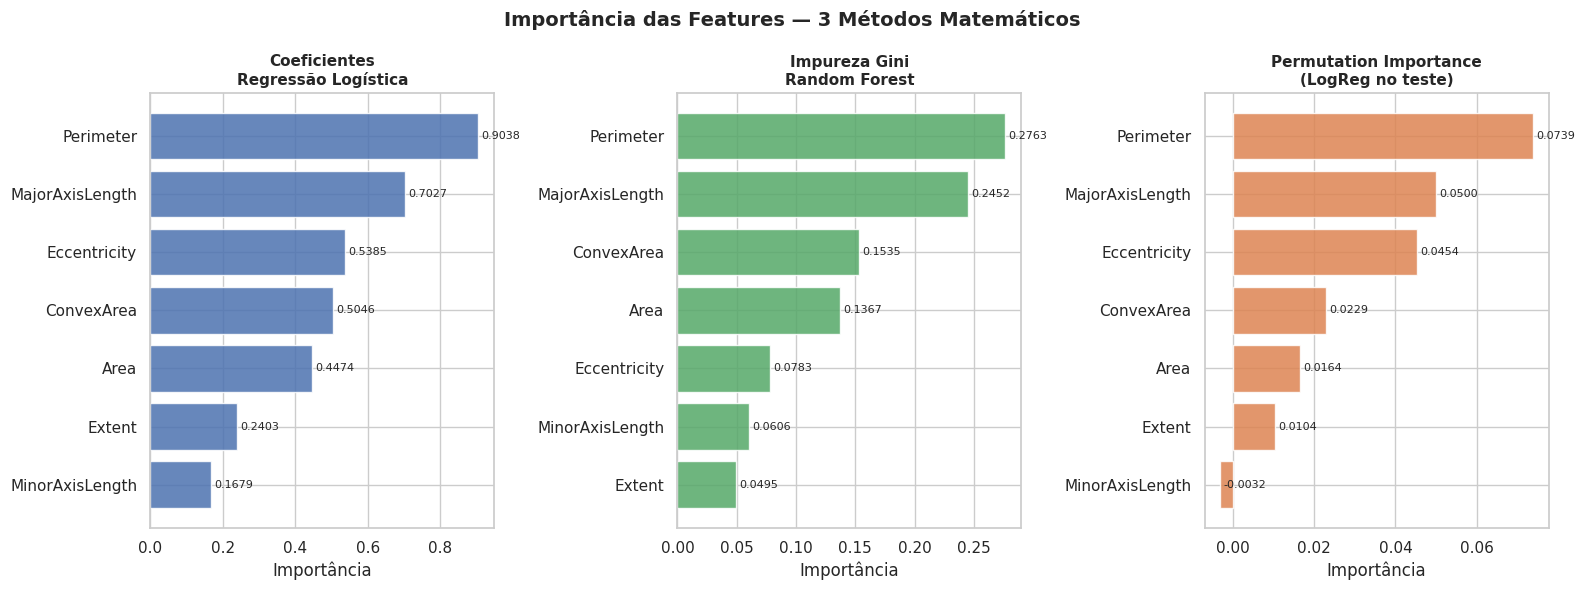

Ranking de importância (Permutation — mais robusto):
  1º Perimeter            0.0739
  2º MajorAxisLength      0.0500
  3º Eccentricity         0.0454
  4º ConvexArea           0.0229
  5º Area                 0.0164
  6º Extent               0.0104
  7º MinorAxisLength      -0.0032


In [40]:
# CÉLULA 40 — Importância das features (3 métodos diferentes)
# ============================================================

# Explicação: existem várias formas de medir a importância de
# uma feature. Vamos usar três abordagens matemáticas distintas
# e comparar se elas concordam entre si.

print("=== ANÁLISE 1: Importância das Features ===\n")

# --- Método 1: Coeficientes da Regressão Logística ---
# Explicação: na Regressão Logística, cada feature tem um
# coeficiente (peso) que indica quanto ela influencia a decisão.
# Coeficiente positivo → empurra para Kecimen
# Coeficiente negativo → empurra para Besni
# Usamos o valor absoluto para medir a importância

coefs = pd.Series(
    np.abs(logreg_final.coef_[0]),
    index=features
).sort_values(ascending=True)

# --- Método 2: Importância por impureza (Random Forest) ---
# Explicação: o Random Forest mede a importância de cada feature
# pelo quanto ela reduz a impureza (Gini) nas divisões das árvores.
# Features que criam divisões mais "limpas" são mais importantes.

importancia_rf = pd.Series(
    rf_final.feature_importances_,
    index=features
).sort_values(ascending=True)

# --- Método 3: Permutation Importance (modelo agnóstico) ---
# Explicação: embaralhamos os valores de uma feature e medimos
# quanto o F1 do modelo cai. Se cair muito, a feature é importante.
# Funciona com qualquer modelo — não depende da estrutura interna.

perm = permutation_importance(
    logreg_final, X_test_scaled, y_test,
    n_repeats=30,        # Explicação: repete o embaralhamento 30 vezes
    random_state=42,
    scoring='f1_macro'
)
importancia_perm = pd.Series(
    perm.importances_mean,
    index=features
).sort_values(ascending=True)

# --- Gráfico comparativo dos 3 métodos ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Importância das Features — 3 Métodos Matemáticos',
             fontsize=14, fontweight='bold')

for ax, (titulo, dados, cor) in zip(axes, [
    ('Coeficientes\nRegressão Logística', coefs, '#4C72B0'),
    ('Impureza Gini\nRandom Forest',      importancia_rf, '#55A868'),
    ('Permutation Importance\n(LogReg no teste)', importancia_perm, '#DD8452')
]):
    barras = ax.barh(dados.index, dados.values, color=cor, alpha=0.85, edgecolor='white')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importância')

    # Explicação: rótulo com o valor em cada barra
    for barra in barras:
        w = barra.get_width()
        ax.text(w + max(dados.values)*0.01, barra.get_y() + barra.get_height()/2,
                f'{w:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Ranking de importância (Permutation — mais robusto):")
for i, (feat, val) in enumerate(importancia_perm.sort_values(ascending=False).items(), 1):
    print(f"  {i}º {feat:<20} {val:.4f}")

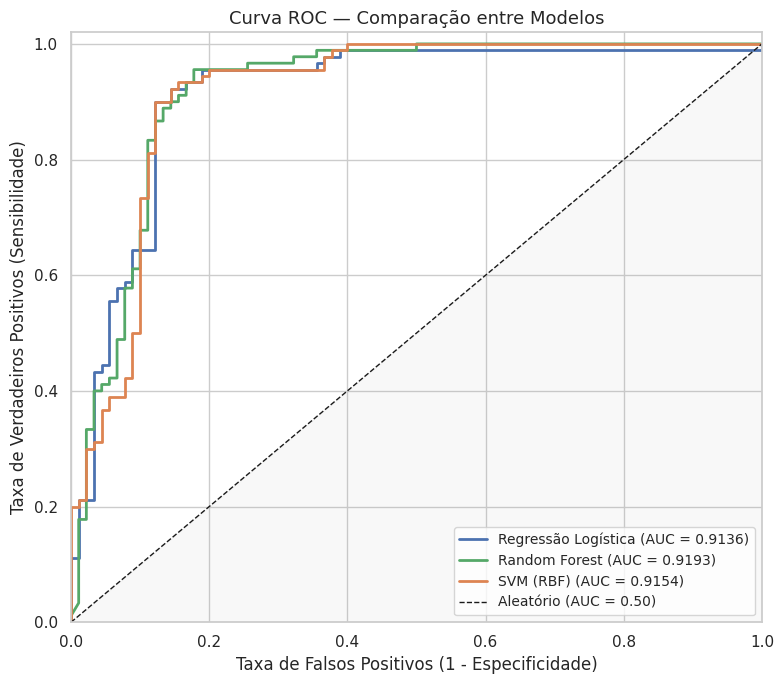

In [41]:
# CÉLULA 41 — Curva ROC e AUC
# ============================================================

# Explicação: a curva ROC (Receiver Operating Characteristic)
# mostra o trade-off entre Taxa de Verdadeiros Positivos (sensibilidade)
# e Taxa de Falsos Positivos (1 - especificidade) em todos os
# limiares de decisão possíveis.
# AUC (Area Under Curve) = 1.0 → modelo perfeito
# AUC = 0.5 → modelo aleatório (igual ao baseline)

from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Explicação: precisamos das probabilidades, não só das classes
# Convertemos o target para 0/1 (Besni=0, Kecimen=1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_test_bin = le.fit_transform(y_test)   # Besni=0, Kecimen=1

fig, ax = plt.subplots(figsize=(8, 7))

cores_roc = {
    'Regressão Logística': ('#4C72B0', logreg_final, X_test_scaled),
    'Random Forest':       ('#55A868', rf_final,     X_test),
    'SVM (RBF)':           ('#DD8452', svm_final,    X_test_scaled),
}

for nome, (cor, modelo, X_tst) in cores_roc.items():
    # Explicação: predict_proba retorna [prob_Besni, prob_Kecimen]
    # usamos a probabilidade da classe positiva (Kecimen = índice 1)
    proba = modelo.predict_proba(X_tst)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, proba)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=cor, linewidth=2,
            label=f'{nome} (AUC = {auc_score:.4f})')

# Explicação: linha diagonal = modelo aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
ax.set_title('Curva ROC — Comparação entre Modelos', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


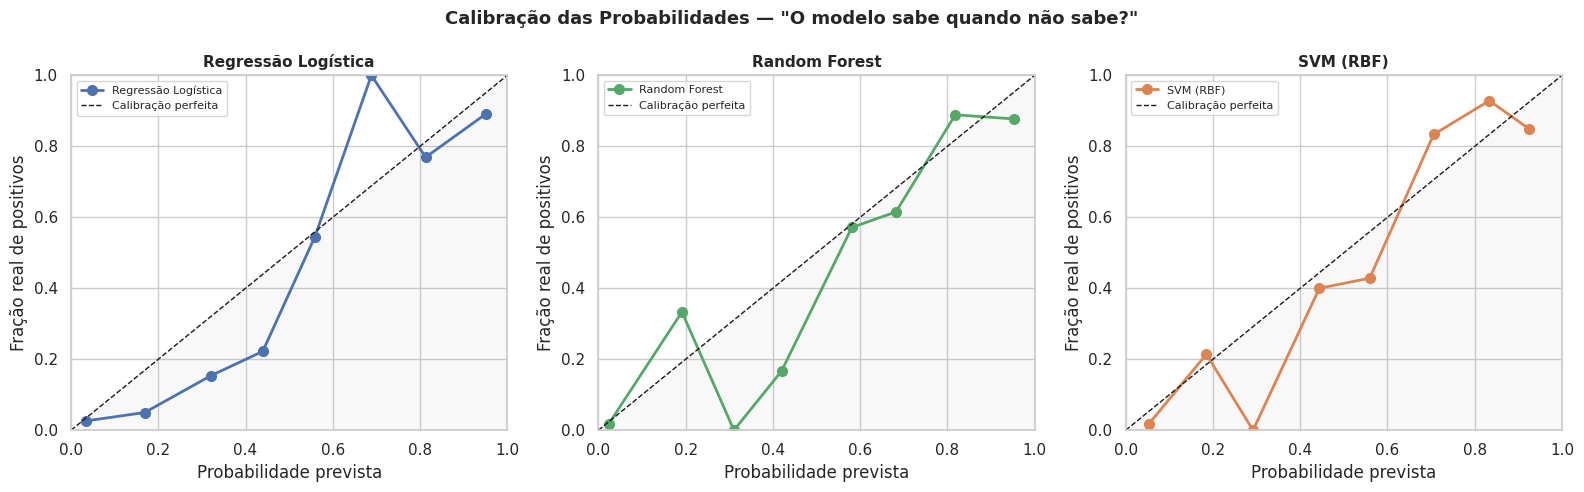

In [42]:
# CÉLULA 42 — Análise de calibração das probabilidades
# ============================================================

# Explicação: um modelo bem calibrado significa que quando ele
# diz "70% de chance de ser Kecimen", de fato ~70% das amostras
# nessa faixa são Kecimen. Isso é crítico em produção industrial:
# um modelo mal calibrado pode dar alta confiança em previsões erradas.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Calibração das Probabilidades — "O modelo sabe quando não sabe?"',
             fontsize=13, fontweight='bold')

for ax, (nome, cor, modelo, X_tst) in zip(axes, [
    ('Regressão Logística', '#4C72B0', logreg_final, X_test_scaled),
    ('Random Forest',       '#55A868', rf_final,     X_test),
    ('SVM (RBF)',           '#DD8452', svm_final,    X_test_scaled),
]):
    proba = modelo.predict_proba(X_tst)[:, 1]

    # Explicação: calibration_curve divide as probabilidades em
    # intervalos e calcula a fração real de positivos em cada um
    prob_true, prob_pred = calibration_curve(
        y_test_bin, proba, n_bins=8, strategy='uniform'
    )

    ax.plot(prob_pred, prob_true, 'o-', color=cor, linewidth=2,
            markersize=7, label=nome)
    # Explicação: linha diagonal perfeita — calibração ideal
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibração perfeita')
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

    ax.set_title(nome, fontsize=11, fontweight='bold')
    ax.set_xlabel('Probabilidade prevista')
    ax.set_ylabel('Fração real de positivos')
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()


Variância explicada: PC1=69.0% | PC2=20.9% | Total=89.9%

Loadings (contribuição de cada feature nas componentes):


,PC1,PC2
Area,0.448,0.114
MajorAxisLength,0.443,-0.138
MinorAxisLength,0.389,0.374
Eccentricity,0.206,-0.607
ConvexArea,0.451,0.084
Extent,-0.048,0.672
Perimeter,0.451,-0.037


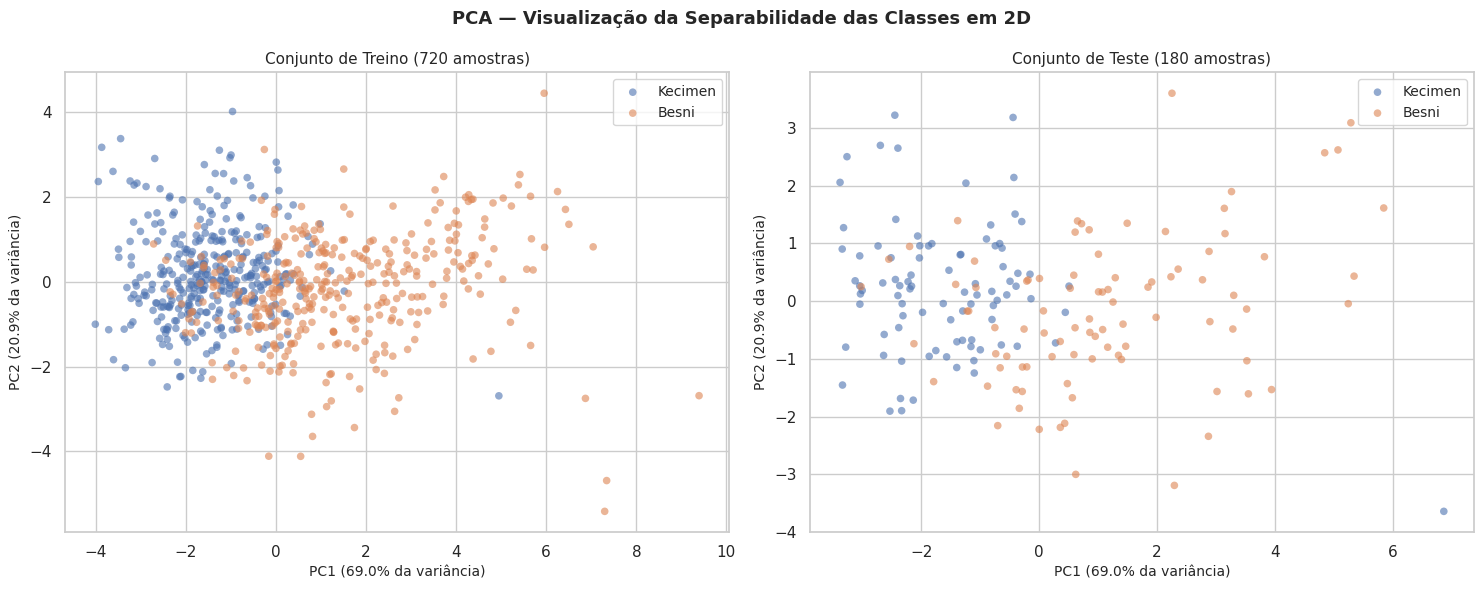

In [43]:
# CÉLULA 43 — PCA: visualização da separabilidade no espaço 2D
# ============================================================

# Explicação: PCA (Principal Component Analysis) é uma técnica
# matemática que comprime as 7 features em 2 dimensões (componentes
# principais) preservando a maior variância possível.
# Isso nos permite visualizar em 2D se as classes são separáveis.
# Cada componente principal é uma combinação linear das features originais.

pca = PCA(n_components=2, random_state=42)

# Explicação: aplicamos PCA nos dados padronizados de treino
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# Explicação: variância explicada — quanto da informação original
# foi preservada nas 2 componentes
var_exp = pca.explained_variance_ratio_
print(f"Variância explicada: PC1={var_exp[0]*100:.1f}% | "
      f"PC2={var_exp[1]*100:.1f}% | "
      f"Total={sum(var_exp)*100:.1f}%")

# Explicação: loadings mostram a contribuição de cada feature
# original para cada componente principal
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(3)
print("\nLoadings (contribuição de cada feature nas componentes):")
display(loadings)

# --- Gráfico: scatter plot no espaço PCA ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('PCA — Visualização da Separabilidade das Classes em 2D',
             fontsize=13, fontweight='bold')

cores_pca = {'Kecimen': '#4C72B0', 'Besni': '#DD8452'}

for ax, (titulo, X_pca, y_pca) in zip(axes, [
    ('Conjunto de Treino (720 amostras)', X_train_pca, y_train),
    ('Conjunto de Teste (180 amostras)',  X_test_pca,  y_test)
]):
    for classe, cor in cores_pca.items():
        mask = np.array(y_pca) == classe
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=cor, label=classe, alpha=0.6, s=30, edgecolors='none')

    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% da variância)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% da variância)', fontsize=10)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


=== ANÁLISE: Testes de Normalidade das Features ===
(Pressuposto fundamental das cartas de controle CEP)

Feature               Shapiro p-valor   KS p-valor    Normal?
--------------------------------------------------------------
Area                         0.000000     0.000000        Nao
MajorAxisLength              0.000000     0.000002        Nao
MinorAxisLength              0.000000     0.011718        Nao
Eccentricity                 0.000000     0.000057        Nao
ConvexArea                   0.000000     0.000023        Nao
Extent                       0.000000     0.011718        Nao
Perimeter                    0.000000     0.078312        Nao

Interpretacao:
   p > 0.05 → dados consistentes com distribuição normal
   p < 0.05 → distribuição não normal → cartas de controle
   podem precisar de transformação (ex: Box-Cox, log)


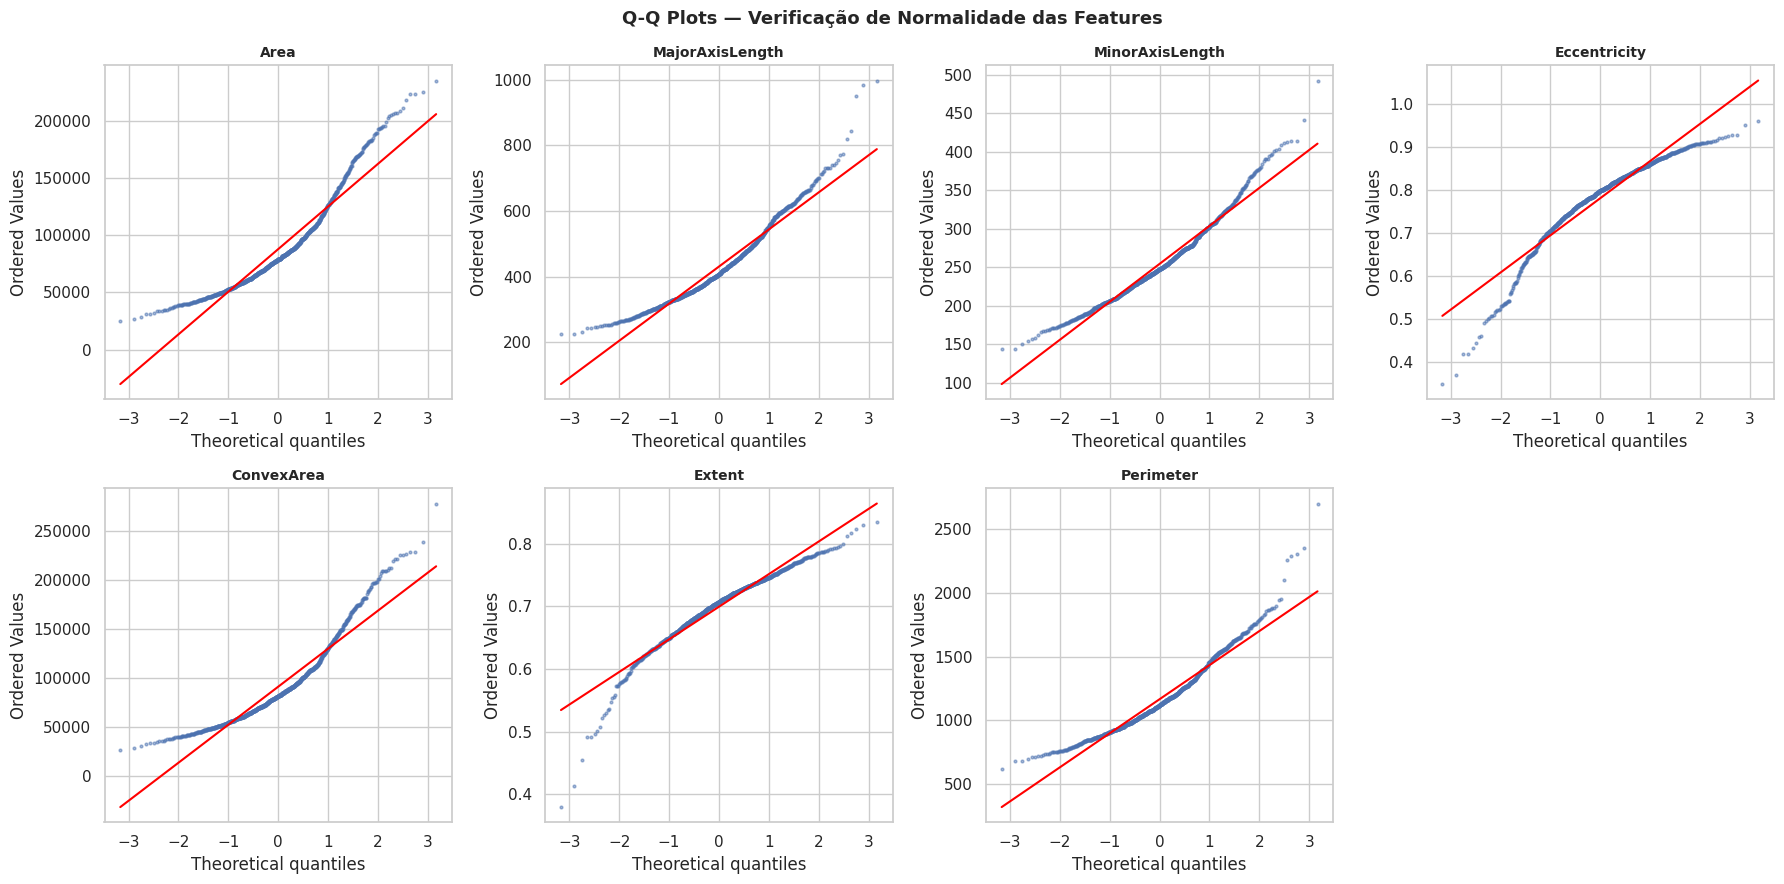

In [44]:
# CÉLULA 44 — Testes de normalidade das features (pressuposto CEP)
# ============================================================

# Explicação: as cartas de controle X-barra, R e p assumem que
# os dados seguem distribuição normal. Vamos testar matematicamente
# essa suposição usando dois testes estatísticos:
#
# Teste de Shapiro-Wilk: hipótese nula = os dados são normais
# Se p-valor > 0.05 → não rejeitamos a normalidade (dados normais)
# Se p-valor < 0.05 → rejeitamos a normalidade (dados não normais)
#
# Teste KS (Kolmogorov-Smirnov): compara a distribuição real
# com uma distribuição normal teórica

print("=== ANÁLISE: Testes de Normalidade das Features ===")
print("(Pressuposto fundamental das cartas de controle CEP)\n")
print(f"{'Feature':<20} {'Shapiro p-valor':>16} {'KS p-valor':>12} {'Normal?':>10}")
print("-" * 62)

resultados_norm = []
for feature in features:
    dados = df[feature].values

    # Explicação: Shapiro-Wilk — mais poderoso para n < 5000
    stat_sw, p_sw = shapiro(dados[:500])  # Shapiro limita a 5000 amostras

    # Explicação: KS — compara com normal de mesma média e desvio
    stat_ks, p_ks = ks_2samp(
        dados,
        np.random.normal(dados.mean(), dados.std(), len(dados))
    )

    normal = "Sim" if p_sw > 0.05 else "Nao"
    print(f"{feature:<20} {p_sw:>16.6f} {p_ks:>12.6f} {normal:>10}")
    resultados_norm.append({'Feature': feature, 'p_shapiro': p_sw,
                            'p_ks': p_ks, 'Normal': p_sw > 0.05})

print("\nInterpretacao:")
print("   p > 0.05 → dados consistentes com distribuição normal")
print("   p < 0.05 → distribuição não normal → cartas de controle")
print("   podem precisar de transformação (ex: Box-Cox, log)")

# Explicação: Q-Q plots para visualizar a normalidade graficamente
# Pontos na diagonal = distribuição normal perfeita
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Q-Q Plots — Verificação de Normalidade das Features',
             fontsize=13, fontweight='bold')

for idx, feature in enumerate(features):
    ax = axes[idx // 4][idx % 4]
    stats.probplot(df[feature].values, dist='norm', plot=ax)
    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.get_lines()[0].set(markersize=2, alpha=0.5)   # pontos menores
    ax.get_lines()[1].set(color='red', linewidth=1.5) # linha vermelha

axes[1][3].set_visible(False)
plt.tight_layout()
plt.show()

=== ANÁLISE: Perfil Matemático dos Erros ===

Total de amostras no teste: 180
Acertos: 158 (87.8%)
Erros:   22   (12.2%)

=== Estatísticas das amostras ERRADAS vs CORRETAS ===



,Média (acertos),Média (erros),Diferença (%)
Area,86236.52,74035.00,-14.1
MajorAxisLength,423.42,401.40,-5.2
MinorAxisLength,253.27,237.42,-6.3
Eccentricity,0.78,0.78,1.1
ConvexArea,89166.32,78850.05,-11.6
Extent,0.70,0.69,-1.8
Perimeter,1148.50,1102.77,-4.0



=== Confiança do modelo (prob. da classe prevista) ===
  Média de confiança nos ACERTOS: 84.5%
  Média de confiança nos ERROS:   74.5%

  [OK] O modelo e mais incerto quando erra.


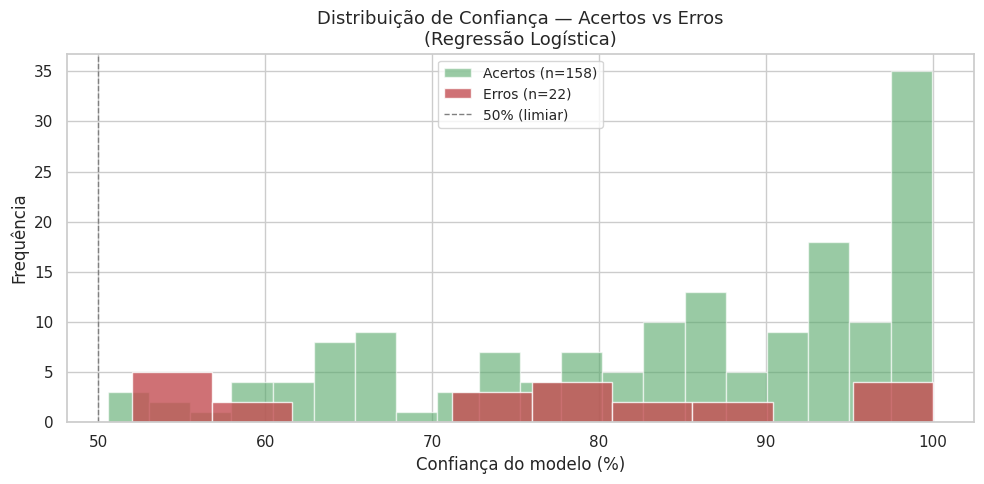

In [45]:
# CÉLULA 45 — Análise de erros: onde e por que o modelo falha
# ============================================================

# Explicação: analisamos matematicamente as amostras que o modelo
# errou para entender se os erros são aleatórios ou sistemáticos.
# Se os erros se concentram em regiões específicas do espaço de
# features, isso indica limitações estruturais do modelo.

print("=== ANÁLISE: Perfil Matemático dos Erros ===\n")

y_pred_lr = logreg_final.predict(X_test_scaled)
y_proba_lr = logreg_final.predict_proba(X_test_scaled)

# Explicação: separamos acertos e erros
acertos = X_test[y_pred_lr == np.array(y_test)].copy()
erros   = X_test[y_pred_lr != np.array(y_test)].copy()

print(f"Total de amostras no teste: {len(X_test)}")
print(f"Acertos: {len(acertos)} ({len(acertos)/len(X_test)*100:.1f}%)")
print(f"Erros:   {len(erros)}   ({len(erros)/len(X_test)*100:.1f}%)")

if len(erros) > 0:
    print("\n=== Estatísticas das amostras ERRADAS vs CORRETAS ===\n")
    comp = pd.DataFrame({
        'Média (acertos)': acertos.mean().round(2),
        'Média (erros)':   erros.mean().round(2),
        'Diferença (%)':   ((erros.mean() - acertos.mean()) /
                             acertos.mean() * 100).round(1)
    })
    display(comp)

# Explicação: analisamos a confiança do modelo nos erros
# Um modelo ideal deveria ter baixa confiança quando erra
confianca = y_proba_lr.max(axis=1)  # probabilidade da classe prevista
confianca_acertos = confianca[y_pred_lr == np.array(y_test)]
confianca_erros   = confianca[y_pred_lr != np.array(y_test)]

print(f"\n=== Confiança do modelo (prob. da classe prevista) ===")
print(f"  Média de confiança nos ACERTOS: {confianca_acertos.mean()*100:.1f}%")
if len(confianca_erros) > 0:
    print(f"  Média de confiança nos ERROS:   {confianca_erros.mean()*100:.1f}%")
    print(f"\n  {'[OK]' if confianca_erros.mean() < confianca_acertos.mean() else '[ATENCAO]'} "
          f"O modelo {'e mais incerto quando erra' if confianca_erros.mean() < confianca_acertos.mean() else 'erra com alta confianca — problema de calibracao'}.")

# Explicação: histograma de confiança separado por acertos e erros
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(confianca_acertos * 100, bins=20, alpha=0.6,
        color='#55A868', label=f'Acertos (n={len(confianca_acertos)})',
        edgecolor='white')
if len(confianca_erros) > 0:
    ax.hist(confianca_erros * 100, bins=10, alpha=0.8,
            color='#C44E52', label=f'Erros (n={len(confianca_erros)})',
            edgecolor='white')
ax.axvline(50, color='gray', linestyle='--', linewidth=1, label='50% (limiar)')
ax.set_xlabel('Confiança do modelo (%)', fontsize=12)
ax.set_ylabel('Frequência', fontsize=12)
ax.set_title('Distribuição de Confiança — Acertos vs Erros\n(Regressão Logística)',
             fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [46]:
# CÉLULA 46 — Resumo matemático final
# ============================================================

print("=" * 60)
print("  RESUMO DAS ANÁLISES MATEMÁTICAS")
print("=" * 60)

# Explicação: coletamos o AUC de cada modelo para o resumo
from sklearn.metrics import roc_auc_score

print("\nAUC-ROC por modelo:")
for nome, (cor, modelo, X_tst) in cores_roc.items():
    proba = modelo.predict_proba(X_tst)[:, 1]
    auc_val = roc_auc_score(y_test_bin, proba)
    print(f"   {nome:<25} AUC = {auc_val:.4f}")

print("\nVariancia explicada pelo PCA (2 componentes):")
print(f"   PC1: {var_exp[0]*100:.1f}% | PC2: {var_exp[1]*100:.1f}% | "
      f"Total: {sum(var_exp)*100:.1f}%")

print("\nNormalidade das features (Shapiro-Wilk, alpha=0.05):")
normais = [r['Feature'] for r in resultados_norm if r['Normal']]
nao_normais = [r['Feature'] for r in resultados_norm if not r['Normal']]
print(f"   Normais:     {normais if normais else 'Nenhuma'}")
print(f"   Não normais: {nao_normais if nao_normais else 'Nenhuma'}")

print("\nFeature mais importante (Permutation Importance):")
mais_imp = importancia_perm.sort_values(ascending=False)
print(f"   1º {mais_imp.index[0]} ({mais_imp.iloc[0]:.4f})")
print(f"   2º {mais_imp.index[1]} ({mais_imp.iloc[1]:.4f})")
print(f"   3º {mais_imp.index[2]} ({mais_imp.iloc[2]:.4f})")

print("\nAnalises matematicas concluidas!")

  RESUMO DAS ANÁLISES MATEMÁTICAS

AUC-ROC por modelo:
   Regressão Logística       AUC = 0.9136
   Random Forest             AUC = 0.9193
   SVM (RBF)                 AUC = 0.9154

Variancia explicada pelo PCA (2 componentes):
   PC1: 69.0% | PC2: 20.9% | Total: 89.9%

Normalidade das features (Shapiro-Wilk, alpha=0.05):
   Normais:     Nenhuma
   Não normais: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']

Feature mais importante (Permutation Importance):
   1º Perimeter (0.0739)
   2º MajorAxisLength (0.0500)
   3º Eccentricity (0.0454)

Analises matematicas concluidas!
